In [2]:
import pandas as pd
import re
import random
import nltk
import string
import numpy as np
import os
import pickle
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
# GLOBAL SEED SETTING
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f" Global seed set to: {SEED}")

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet

 Global seed set to: 42


In [4]:
# LOAD DATA
df = pd.read_csv("/content/TomLem.csv")
print(" Data Awal:")
print(df.head())
print(f"Shape: {df.shape}")
print(f"Distribusi sentimen:\n{df['sentimen'].value_counts()}")

 Data Awal:
                                         textDisplay sentimen
0                              strategi politik basi  negatif
1                 labil plinpan basi dan ah sudahlah  negatif
2                                       ya begitulah   netral
3  hanya tom seorang yg layak mengapresiasi aboli...  negatif
4  gmn bg aturan aneh yg banyak dikaji dan diujic...  negatif
Shape: (1029, 2)
Distribusi sentimen:
sentimen
negatif    551
positif    315
netral     163
Name: count, dtype: int64


In [12]:
# DATA AUGMENTATION
print("\nCreating new augmented dataset...")

def synonym_replacement(sentence, n=2):
    words = sentence.split()
    if len(words) < 2:
        return sentence

    new_words = words.copy()
    meaningful_words = [word for word in words if len(word) > 3 and wordnet.synsets(word)]

    if not meaningful_words:
        return sentence

    np.random.shuffle(meaningful_words)
    num_replaced = 0

    for word in meaningful_words:
        synonyms = wordnet.synsets(word)
        if synonyms and num_replaced < n:
            lemmas = synonyms[0].lemmas()
            if len(lemmas) > 1:
                synonym = lemmas[1].name().replace('_', ' ')
                if synonym != word and len(synonym) > 2:
                    new_words = [synonym if w == word else w for w in new_words]
                    num_replaced += 1

    return ' '.join(new_words)


def random_insertion(sentence, n=1):
    words = sentence.split()
    if len(words) < 3:
        return sentence

    new_words = words.copy()
    for _ in range(n):
        random_word = np.random.choice(words)
        synonyms = wordnet.synsets(random_word)
        if synonyms:
            lemmas = synonyms[0].lemmas()
            if len(lemmas) > 1:
                synonym = lemmas[1].name().replace('_', ' ')
                random_idx = np.random.randint(0, len(new_words) + 1)
                new_words.insert(random_idx, synonym)

    return ' '.join(new_words)


def random_deletion(sentence, p=0.1):
    words = sentence.split()
    if len(words) < 4:
        return sentence

    new_words = []
    for word in words:
        if np.random.uniform(0, 1) > p:
            new_words.append(word)

    if len(new_words) == 0:
        return words[0]

    return ' '.join(new_words)


augmented_data = []
for idx, (text, label) in enumerate(zip(df['textDisplay'], df['sentimen'])):
    # Original
    augmented_data.append({'textDisplay': text, 'sentimen': label, 'augmentation': 'original', 'original_idx': idx})

    # Synonym replacement
    aug1 = synonym_replacement(text, n=2)
    if aug1 != text:
        augmented_data.append({'textDisplay': aug1, 'sentimen': label, 'augmentation': 'synonym', 'original_idx': idx})

    # Random insertion
    if len(text.split()) > 5:
        aug2 = random_insertion(text, n=1)
        if aug2 != text:
            augmented_data.append({'textDisplay': aug2, 'sentimen': label, 'augmentation': 'insertion', 'original_idx': idx})

    # Random deletion
    if len(text.split()) > 6:
        aug3 = random_deletion(text, p=0.15)
        if aug3 != text and len(aug3.split()) > 2:
            augmented_data.append({'textDisplay': aug3, 'sentimen': label, 'augmentation': 'deletion', 'original_idx': idx})

df_final = pd.DataFrame(augmented_data)

print(f"\nData setelah Enhanced Augmentation:")
print(f"Original data: {len(df)}")
print(f"Augmented data: {len(df_final)}")
print(f"Augmentation distribution:\n{df_final['augmentation'].value_counts()}")


Creating new augmented dataset...

Data setelah Enhanced Augmentation:
Original data: 1027
Augmented data: 2117
Augmentation distribution:
augmentation
original     1027
deletion      622
synonym       389
insertion      79
Name: count, dtype: int64


In [ ]:
# EVALUATION SETUP

def calculate_comprehensive_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'classification_report': classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    }

all_model_results = []


In [ ]:
# BASELINE MODEL EVALUATION

print(f"\n{'='*80}")
print("BASELINE MODEL EVALUATION")
print(f"{'='*80}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df_final['textDisplay'],
    df_final['sentimen'],
    test_size=0.2,
    random_state=SEED,
    stratify=df_final['sentimen']
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training set distribution:\n{y_train.value_counts()}")

baseline_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)
X_train_baseline = baseline_vectorizer.fit_transform(X_train)
X_test_baseline = baseline_vectorizer.transform(X_test)

vectorizers = {
    'tfidf_unigram': TfidfVectorizer(
        ngram_range=(1,1),
        max_features=5000,
        min_df=2,
        max_df=0.8
    ),
    'tfidf_bigram': TfidfVectorizer(
        ngram_range=(1,2),
        max_features=8000,
        min_df=2,
        max_df=0.8
    ),
    'tfidf_trigram': TfidfVectorizer(
        ngram_range=(1,3),
        max_features=10000,
        min_df=2,
        max_df=0.8
    ),
    'count_vec': CountVectorizer(
        ngram_range=(1,2),
        max_features=5000,
        min_df=2,
        max_df=0.8
    )
}



BASELINE MODEL EVALUATION
Training set size: 1735
Test set size: 434
Training set distribution:
sentimen
negatif    973
positif    508
netral     254
Name: count, dtype: int64


In [ ]:
# FEATURE ENGINEERING &  MODELS

print(f"\n{'='*80}")
print(" MODEL EVALUATION")
print(f"{'='*80}")

vectorizers = {
    'tfidf_unigram': TfidfVectorizer(ngram_range=(1,1), max_features=5000, min_df=2, max_df=0.8),
    'tfidf_bigram': TfidfVectorizer(ngram_range=(1,2), max_features=8000, min_df=2, max_df=0.8),
    'tfidf_trigram': TfidfVectorizer(ngram_range=(1,3), max_features=10000, min_df=2, max_df=0.8),
    'count_vec': CountVectorizer(ngram_range=(1,2), max_features=5000, min_df=2, max_df=0.8)
}


def train_and_evaluate_models(X_train, X_test, y_train, y_test, vectorizer_name):

    results = {}

    models = {
        'SVM': {
            'model': SVC(probability=True, random_state=SEED),
            'params': {
                'C': [0.1, 1, 10],
                'kernel': ['linear', 'rbf'],
                'gamma': ['scale', 'auto']
            }
        },
        'Naive Bayes': {
            'model': MultinomialNB(),
            'params': {
                'alpha': [0.1, 0.5, 1.0, 2.0]
            }
        },
        'Logistic Regression': {
            'model': LogisticRegression(random_state=SEED, max_iter=500),
            'params': {
                'C': [0.1, 1, 10],
                'solver': ['liblinear', 'lbfgs']
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=SEED, n_estimators=100),
            'params': {
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        },
        'Gradient Boosting': {
            'model': GradientBoostingClassifier(random_state=SEED),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.05, 0.1, 0.2],
                'max_depth': [3, 5, 7]
            }
        }
    }

    best_models = {}

    for name, config in models.items():
        print(f"Training {name} with {vectorizer_name}...")

        # Grid search dan cross-validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        grid_search = GridSearchCV(
    config['model'],
    config['params'],
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)


        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        metrics = calculate_comprehensive_metrics(y_test, y_pred)

        results[name] = {
            'model': best_model,
            'best_params': grid_search.best_params_,
            'predictions': y_pred,
            'metrics': metrics,
            'model_type': 'Advanced'
        }

        best_models[name.lower().replace(' ', '_')] = best_model
        all_model_results.append({
            'Model': name,
            'Type': 'Advanced',
            'Vectorizer': vectorizer_name,
            **{k: v for k, v in metrics.items() if k != 'classification_report'}
        })

        print(f"{name} - Accuracy: {metrics['accuracy']:.4f}, F1-weighted: {metrics['f1_weighted']:.4f}")

    return results, best_models

all_results = {}
all_vectorized_data = {}

for vec_name, vectorizer in vectorizers.items():
    print(f"\n{'='*50}")
    print(f"TRAINING WITH {vec_name.upper()}")
    print(f"{'='*50}")

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    all_vectorized_data[vec_name] = {
        'X_train': X_train_vec,
        'X_test': X_test_vec,
        'vectorizer': vectorizer
    }

    results, best_models = train_and_evaluate_models(
        X_train_vec, X_test_vec, y_train, y_test, vec_name
    )

    all_results[vec_name] = results


 MODEL EVALUATION

TRAINING WITH TFIDF_UNIGRAM
Training SVM with tfidf_unigram...
SVM - Accuracy: 0.9608, F1-weighted: 0.9602
Training Naive Bayes with tfidf_unigram...
Naive Bayes - Accuracy: 0.8710, F1-weighted: 0.8642
Training Logistic Regression with tfidf_unigram...
Logistic Regression - Accuracy: 0.9332, F1-weighted: 0.9323
Training Random Forest with tfidf_unigram...
Random Forest - Accuracy: 0.9355, F1-weighted: 0.9355
Training Gradient Boosting with tfidf_unigram...
Gradient Boosting - Accuracy: 0.9124, F1-weighted: 0.9119

TRAINING WITH TFIDF_BIGRAM
Training SVM with tfidf_bigram...
SVM - Accuracy: 0.9608, F1-weighted: 0.9603
Training Naive Bayes with tfidf_bigram...
Naive Bayes - Accuracy: 0.8825, F1-weighted: 0.8768
Training Logistic Regression with tfidf_bigram...
Logistic Regression - Accuracy: 0.9401, F1-weighted: 0.9393
Training Random Forest with tfidf_bigram...
Random Forest - Accuracy: 0.9309, F1-weighted: 0.9312
Training Gradient Boosting with tfidf_bigram...
Gradi

In [ ]:
# CREATE  ENSEMBLE
print(f"\n{'='*80}")
print("CREATING ENSEMBLE")
print(f"{'='*80}")

ensemble_models = []
ensemble_names = []

for vec_name, results in all_results.items():

    best_model_name = max(results.keys(), key=lambda x: results[x]['metrics']['f1_weighted'])
    best_model = results[best_model_name]['model']

    pipeline = Pipeline([
        ('vectorizer', all_vectorized_data[vec_name]['vectorizer']),
        ('classifier', best_model)
    ])

    ensemble_models.append((f"{best_model_name}_{vec_name}", pipeline))
    ensemble_names.append(f"{best_model_name} ({vec_name})")


voting_ensemble = VotingClassifier(
    estimators=ensemble_models,
    voting='soft'
)

print("Training advanced ensemble...")
voting_ensemble.fit(X_train, y_train)
ensemble_pred = voting_ensemble.predict(X_test)


ensemble_metrics = calculate_comprehensive_metrics(y_test, ensemble_pred)

all_model_results.append({
    'Model': 'Voting Ensemble',
    'Type': 'Ensemble',
    'Vectorizer': 'Multi-Vectorizer',
    **{k: v for k, v in ensemble_metrics.items() if k != 'classification_report'}
})

print(f"Advanced Ensemble - Accuracy: {ensemble_metrics['accuracy']:.4f}, F1-weighted: {ensemble_metrics['f1_weighted']:.4f}")


CREATING ENSEMBLE
Training advanced ensemble...
Advanced Ensemble - Accuracy: 0.9516, F1-weighted: 0.9516


In [ ]:

# COMPREHENSIVE RESULTS COMPARISON

print(f"\n{'='*80}")
print(" COMPREHENSIVE RESULTS COMPARISON")
print(f"{'='*80}")

results_df = pd.DataFrame(all_model_results)
results_df = results_df.sort_values(['f1_weighted', 'accuracy'], ascending=False)

print("\n MODEL PERFORMANCE COMPARISON:")
display_columns = ['Model', 'Type', 'Vectorizer', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
print(results_df[display_columns].round(4).to_string(index=False))

best_result = results_df.iloc[0]
print(f"\nBEST MODEL:")
print(f"   Model: {best_result['Model']}")
print(f"   Type: {best_result['Type']}")
print(f"   Vectorizer: {best_result['Vectorizer']}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")
print(f"   F1-weighted: {best_result['f1_weighted']:.4f}")

results_df.to_csv('model_comparison_results.csv', index=False)
print(f"\nResults saved to model_comparison_results.csv")


 COMPREHENSIVE RESULTS COMPARISON

 MODEL PERFORMANCE COMPARISON:
              Model     Type       Vectorizer  accuracy  precision_weighted  recall_weighted  f1_weighted
                SVM Advanced     tfidf_bigram    0.9608              0.9608           0.9608       0.9603
                SVM Advanced    tfidf_unigram    0.9608              0.9609           0.9608       0.9602
                SVM Advanced    tfidf_trigram    0.9585              0.9584           0.9585       0.9580
    Voting Ensemble Ensemble Multi-Vectorizer    0.9516              0.9517           0.9516       0.9516
Logistic Regression Advanced        count_vec    0.9401              0.9405           0.9401       0.9402
Logistic Regression Advanced     tfidf_bigram    0.9401              0.9407           0.9401       0.9393
                SVM Advanced        count_vec    0.9401              0.9409           0.9401       0.9392
      Random Forest Advanced    tfidf_unigram    0.9355              0.9358          

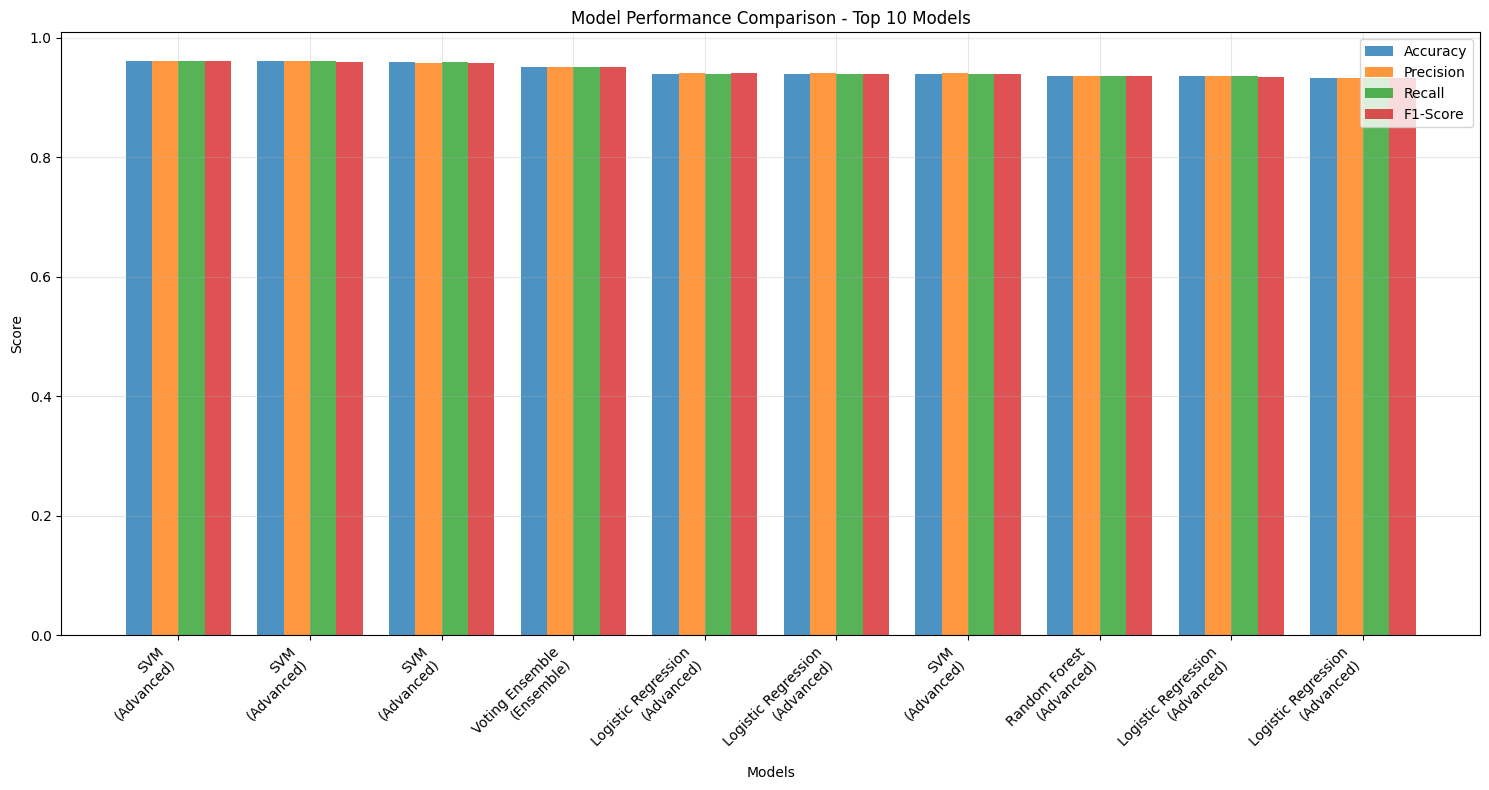

In [ ]:
# MODEL PERFORMANCE COMPARISON CHARTS

plt.figure(figsize=(15, 8))

# Select top models
top_models = results_df.head(10)
model_names = [f"{row['Model']}\n({row['Type']})" for _, row in top_models.iterrows()]

x = np.arange(len(model_names))
width = 0.2

plt.bar(x - width*1.5, top_models['accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar(x - width/2, top_models['precision_weighted'], width, label='Precision', alpha=0.8)
plt.bar(x + width/2, top_models['recall_weighted'], width, label='Recall', alpha=0.8)
plt.bar(x + width*1.5, top_models['f1_weighted'], width, label='F1-Score', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison - Top 10 Models')
plt.xticks(x, model_names, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# CLASSIFICATION REPORT & SAVE PIPELINE


print(f"\n{'='*80}")
print(" CLASSIFICATION REPORTS")
print(f"{'='*80}")

# Classification report untuk ensemble
print("\nClassification Report - Voting Ensemble:")
print(classification_report(y_test, ensemble_pred, zero_division=0))

# Classification report untuk best overall model (dari results_df)
best_model_name = best_result['Model']
best_vectorizer_name = best_result['Vectorizer']

if best_model_name == "Voting Ensemble":
    final_pipeline = voting_ensemble
else:
    # Ambil model & vectorizer terbaik
    best_model_info = all_results[best_vectorizer_name][best_model_name]
    best_vectorizer = all_vectorized_data[best_vectorizer_name]['vectorizer']
    best_model = best_model_info['model']

    # Buat pipeline untuk disimpan
    final_pipeline = Pipeline([
        ('vectorizer', best_vectorizer),
        ('classifier', best_model)
    ])

    # Classification report best single model
    y_pred_best = final_pipeline.predict(X_test)
    print(f"\nClassification Report - Best Model ({best_model_name} with {best_vectorizer_name}):")
    print(classification_report(y_test, y_pred_best, zero_division=0))



 CLASSIFICATION REPORTS

Classification Report - Voting Ensemble:
              precision    recall  f1-score   support

     negatif       0.97      0.96      0.96       244
      netral       0.90      0.90      0.90        63
     positif       0.95      0.96      0.95       127

    accuracy                           0.95       434
   macro avg       0.94      0.94      0.94       434
weighted avg       0.95      0.95      0.95       434


Classification Report - Best Model (SVM with tfidf_bigram):
              precision    recall  f1-score   support

     negatif       0.96      0.99      0.97       244
      netral       0.95      0.86      0.90        63
     positif       0.98      0.96      0.97       127

    accuracy                           0.96       434
   macro avg       0.96      0.94      0.95       434
weighted avg       0.96      0.96      0.96       434




 CLASSIFICATION REPORTS & CONFUSION MATRICES

Classification Report - SVM (tfidf_unigram):
              precision    recall  f1-score   support

     negatif       0.95      0.99      0.97       244
      netral       0.95      0.84      0.89        63
     positif       0.98      0.96      0.97       127

    accuracy                           0.96       434
   macro avg       0.96      0.93      0.94       434
weighted avg       0.96      0.96      0.96       434



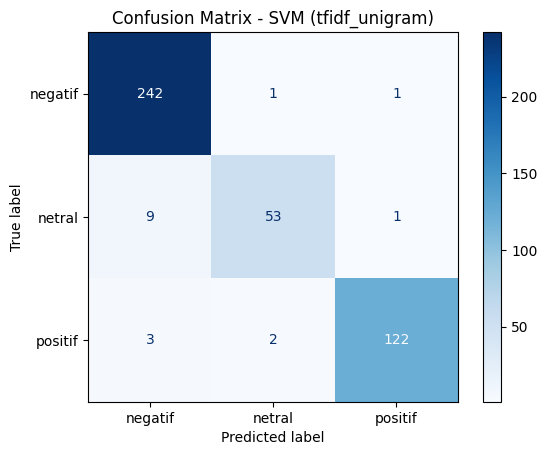


Classification Report - Naive Bayes (tfidf_unigram):
              precision    recall  f1-score   support

     negatif       0.84      0.97      0.90       244
      netral       0.92      0.54      0.68        63
     positif       0.94      0.84      0.89       127

    accuracy                           0.87       434
   macro avg       0.90      0.78      0.82       434
weighted avg       0.88      0.87      0.86       434



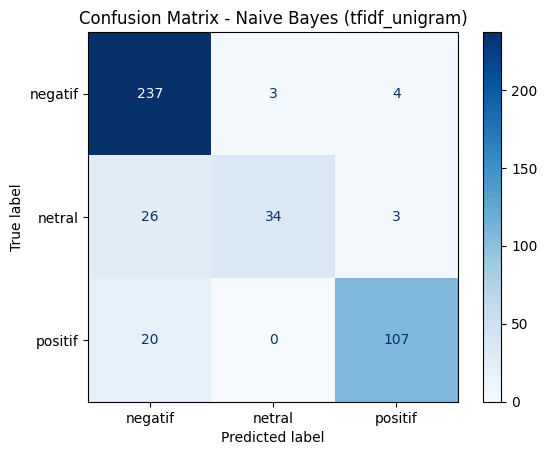


Classification Report - Logistic Regression (tfidf_unigram):
              precision    recall  f1-score   support

     negatif       0.93      0.96      0.95       244
      netral       0.91      0.79      0.85        63
     positif       0.94      0.94      0.94       127

    accuracy                           0.93       434
   macro avg       0.93      0.90      0.91       434
weighted avg       0.93      0.93      0.93       434



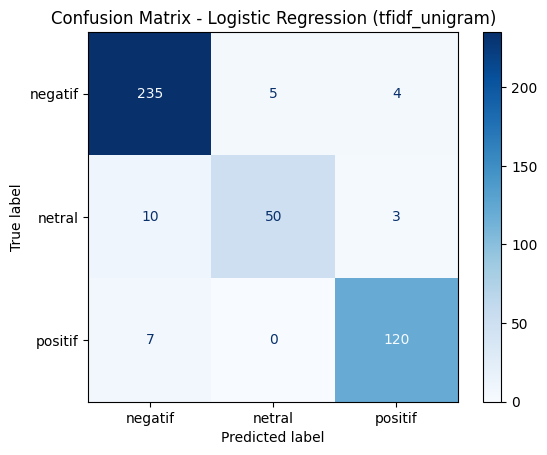


Classification Report - Random Forest (tfidf_unigram):
              precision    recall  f1-score   support

     negatif       0.95      0.95      0.95       244
      netral       0.88      0.90      0.89        63
     positif       0.94      0.91      0.93       127

    accuracy                           0.94       434
   macro avg       0.92      0.92      0.92       434
weighted avg       0.94      0.94      0.94       434



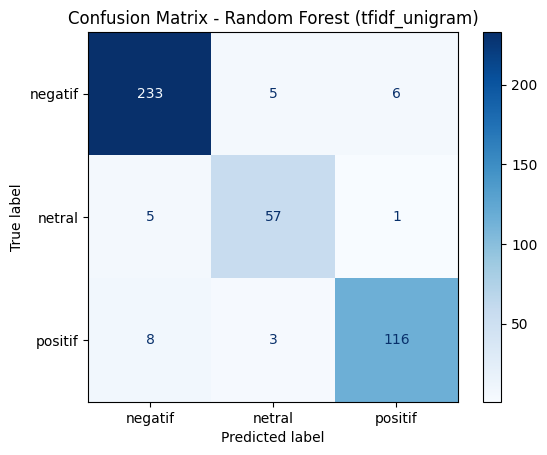


Classification Report - Gradient Boosting (tfidf_unigram):
              precision    recall  f1-score   support

     negatif       0.90      0.95      0.93       244
      netral       0.86      0.81      0.84        63
     positif       0.96      0.88      0.92       127

    accuracy                           0.91       434
   macro avg       0.91      0.88      0.89       434
weighted avg       0.91      0.91      0.91       434



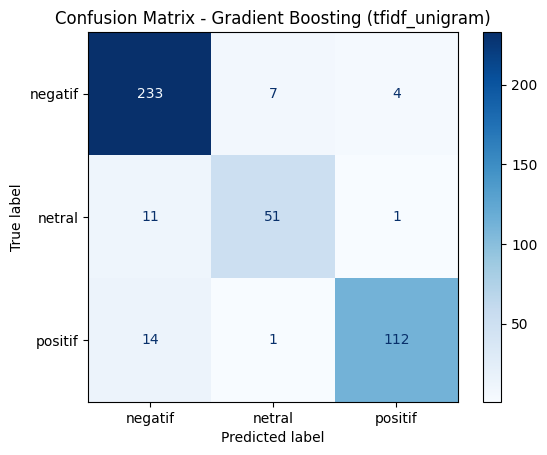


Classification Report - SVM (tfidf_bigram):
              precision    recall  f1-score   support

     negatif       0.96      0.99      0.97       244
      netral       0.95      0.86      0.90        63
     positif       0.98      0.96      0.97       127

    accuracy                           0.96       434
   macro avg       0.96      0.94      0.95       434
weighted avg       0.96      0.96      0.96       434



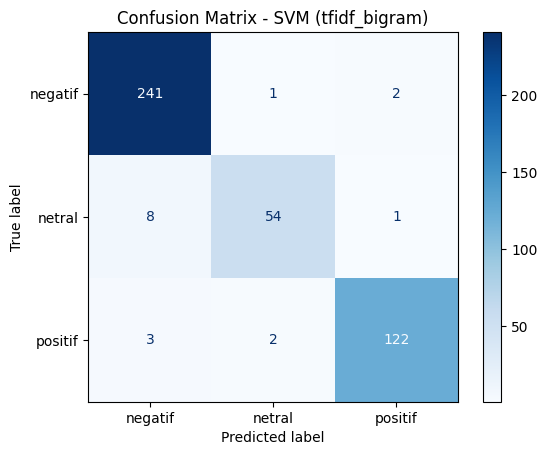


Classification Report - Naive Bayes (tfidf_bigram):
              precision    recall  f1-score   support

     negatif       0.86      0.97      0.91       244
      netral       0.90      0.57      0.70        63
     positif       0.93      0.87      0.90       127

    accuracy                           0.88       434
   macro avg       0.90      0.80      0.84       434
weighted avg       0.89      0.88      0.88       434



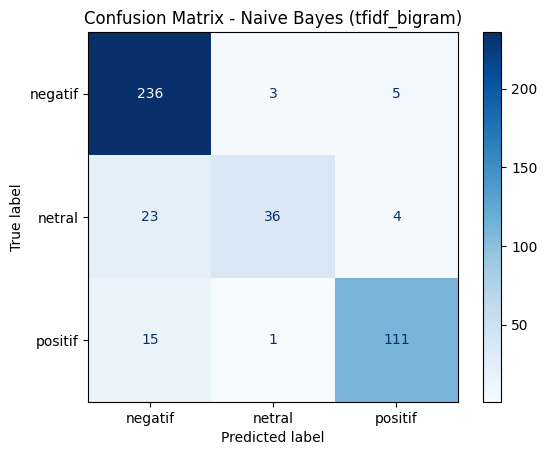


Classification Report - Logistic Regression (tfidf_bigram):
              precision    recall  f1-score   support

     negatif       0.94      0.97      0.95       244
      netral       0.96      0.81      0.88        63
     positif       0.94      0.95      0.95       127

    accuracy                           0.94       434
   macro avg       0.95      0.91      0.93       434
weighted avg       0.94      0.94      0.94       434



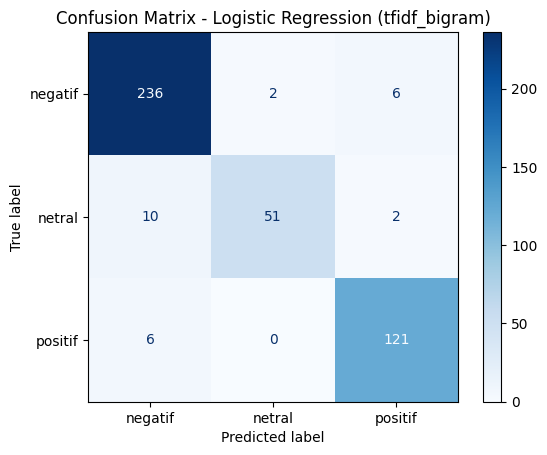


Classification Report - Random Forest (tfidf_bigram):
              precision    recall  f1-score   support

     negatif       0.95      0.95      0.95       244
      netral       0.84      0.92      0.88        63
     positif       0.95      0.90      0.92       127

    accuracy                           0.93       434
   macro avg       0.91      0.92      0.92       434
weighted avg       0.93      0.93      0.93       434



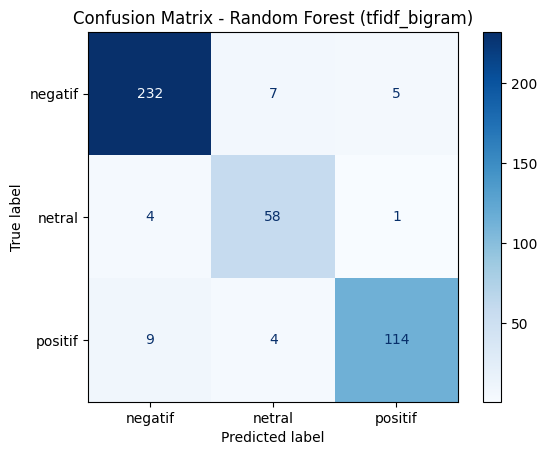


Classification Report - Gradient Boosting (tfidf_bigram):
              precision    recall  f1-score   support

     negatif       0.92      0.92      0.92       244
      netral       0.78      0.83      0.80        63
     positif       0.92      0.90      0.91       127

    accuracy                           0.90       434
   macro avg       0.87      0.88      0.88       434
weighted avg       0.90      0.90      0.90       434



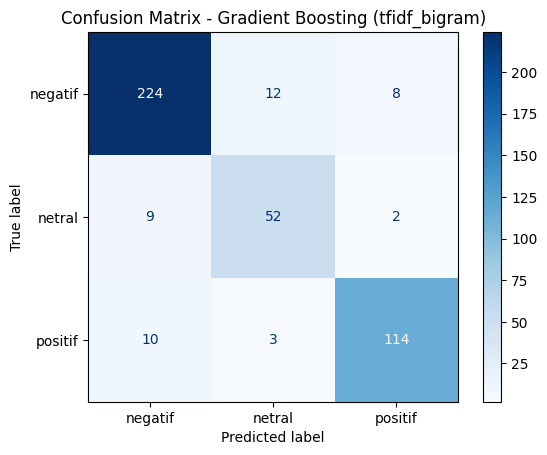


Classification Report - SVM (tfidf_trigram):
              precision    recall  f1-score   support

     negatif       0.96      0.98      0.97       244
      netral       0.95      0.86      0.90        63
     positif       0.97      0.96      0.96       127

    accuracy                           0.96       434
   macro avg       0.96      0.93      0.94       434
weighted avg       0.96      0.96      0.96       434



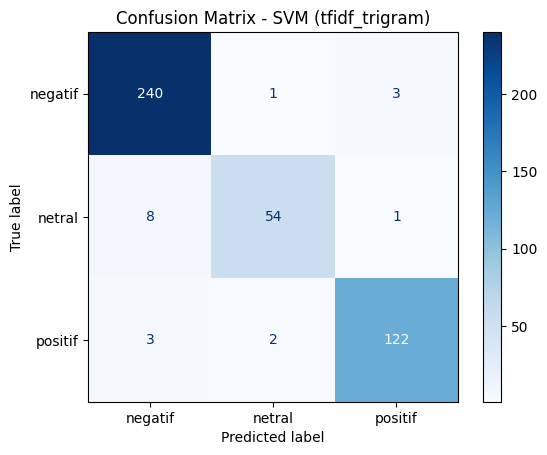


Classification Report - Naive Bayes (tfidf_trigram):
              precision    recall  f1-score   support

     negatif       0.84      0.97      0.90       244
      netral       0.88      0.56      0.68        63
     positif       0.94      0.83      0.88       127

    accuracy                           0.87       434
   macro avg       0.88      0.79      0.82       434
weighted avg       0.87      0.87      0.86       434



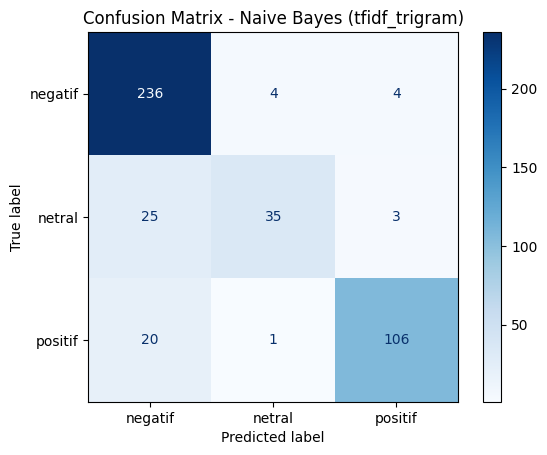


Classification Report - Logistic Regression (tfidf_trigram):
              precision    recall  f1-score   support

     negatif       0.93      0.97      0.95       244
      netral       0.96      0.81      0.88        63
     positif       0.94      0.94      0.94       127

    accuracy                           0.94       434
   macro avg       0.94      0.90      0.92       434
weighted avg       0.94      0.94      0.93       434



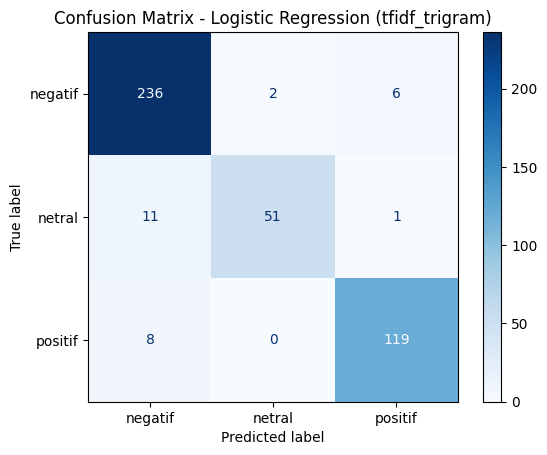


Classification Report - Random Forest (tfidf_trigram):
              precision    recall  f1-score   support

     negatif       0.93      0.96      0.94       244
      netral       0.86      0.87      0.87        63
     positif       0.96      0.87      0.91       127

    accuracy                           0.92       434
   macro avg       0.91      0.90      0.91       434
weighted avg       0.92      0.92      0.92       434



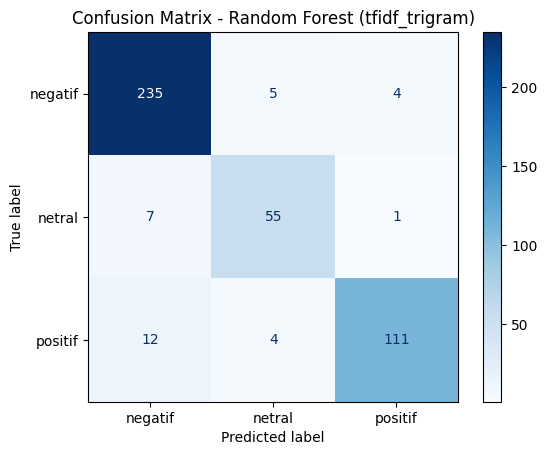


Classification Report - Gradient Boosting (tfidf_trigram):
              precision    recall  f1-score   support

     negatif       0.90      0.94      0.92       244
      netral       0.89      0.76      0.82        63
     positif       0.92      0.91      0.91       127

    accuracy                           0.90       434
   macro avg       0.90      0.87      0.88       434
weighted avg       0.90      0.90      0.90       434



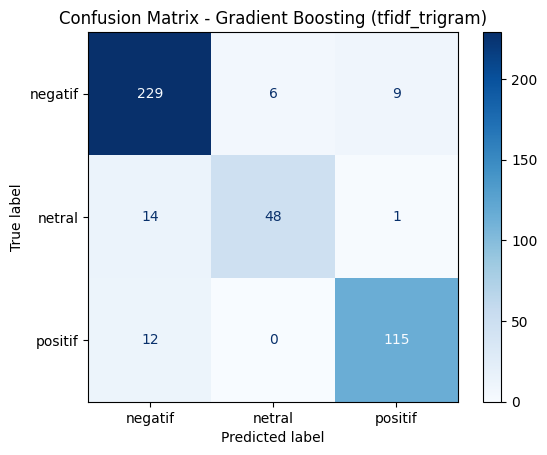


Classification Report - SVM (count_vec):
              precision    recall  f1-score   support

     negatif       0.93      0.98      0.95       244
      netral       0.96      0.81      0.88        63
     positif       0.95      0.94      0.94       127

    accuracy                           0.94       434
   macro avg       0.95      0.91      0.93       434
weighted avg       0.94      0.94      0.94       434



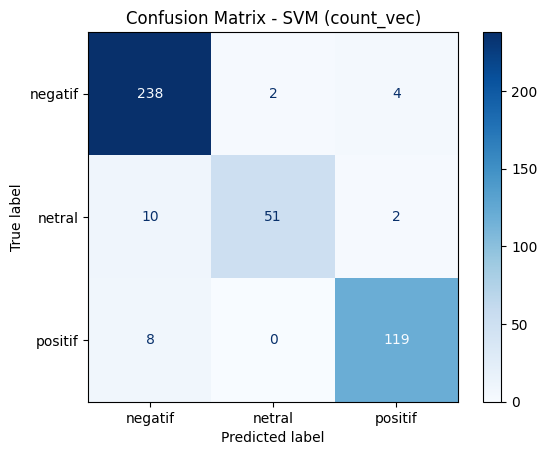


Classification Report - Naive Bayes (count_vec):
              precision    recall  f1-score   support

     negatif       0.87      0.93      0.90       244
      netral       0.82      0.67      0.74        63
     positif       0.89      0.85      0.87       127

    accuracy                           0.87       434
   macro avg       0.86      0.82      0.83       434
weighted avg       0.87      0.87      0.87       434



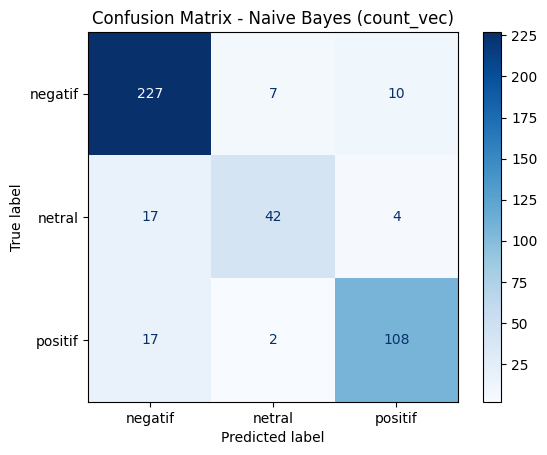


Classification Report - Logistic Regression (count_vec):
              precision    recall  f1-score   support

     negatif       0.96      0.95      0.95       244
      netral       0.88      0.90      0.89        63
     positif       0.94      0.94      0.94       127

    accuracy                           0.94       434
   macro avg       0.92      0.93      0.93       434
weighted avg       0.94      0.94      0.94       434



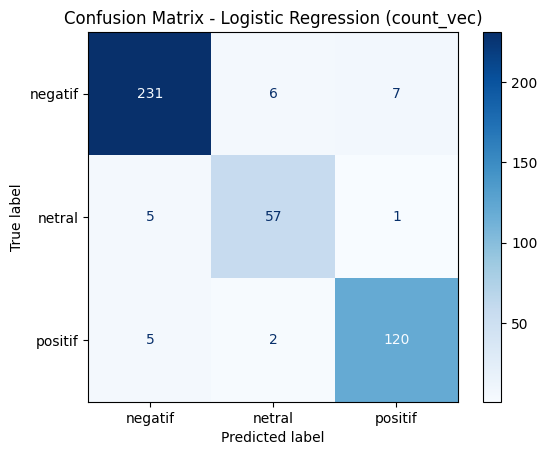


Classification Report - Random Forest (count_vec):
              precision    recall  f1-score   support

     negatif       0.93      0.95      0.94       244
      netral       0.85      0.84      0.85        63
     positif       0.95      0.92      0.94       127

    accuracy                           0.93       434
   macro avg       0.91      0.90      0.91       434
weighted avg       0.93      0.93      0.93       434



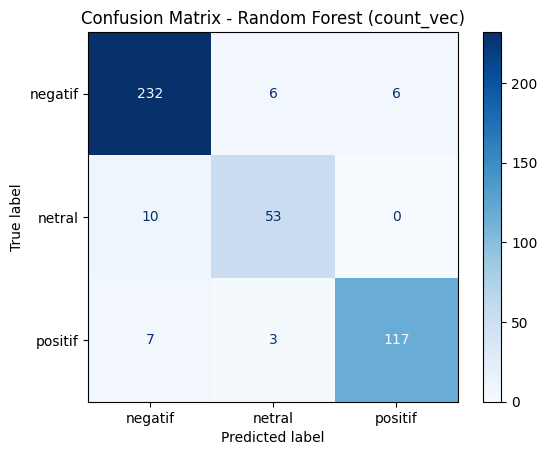


Classification Report - Gradient Boosting (count_vec):
              precision    recall  f1-score   support

     negatif       0.90      0.99      0.94       244
      netral       1.00      0.71      0.83        63
     positif       0.97      0.91      0.94       127

    accuracy                           0.93       434
   macro avg       0.95      0.87      0.90       434
weighted avg       0.93      0.93      0.92       434



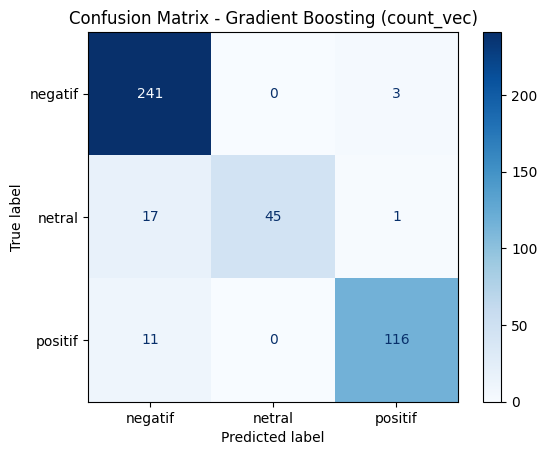


Classification Report - Voting Ensemble:
              precision    recall  f1-score   support

     negatif       0.97      0.96      0.96       244
      netral       0.90      0.90      0.90        63
     positif       0.95      0.96      0.95       127

    accuracy                           0.95       434
   macro avg       0.94      0.94      0.94       434
weighted avg       0.95      0.95      0.95       434



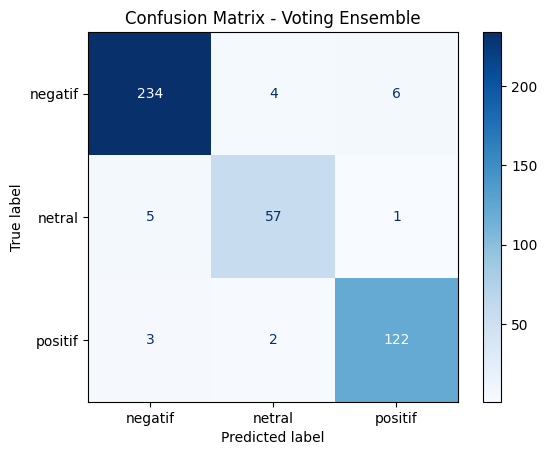

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

#CLASSIFICATION REPORT & CONFUSION MATRIX

print(f"\n{'='*80}")
print(" CLASSIFICATION REPORTS & CONFUSION MATRICES")
print(f"{'='*80}")

# Simpan semua pipeline di dict
saved_pipelines = {}

# Evaluasi semua model per vectorizer
for vec_name, results in all_results.items():
    for model_name, info in results.items():
        print(f"\nClassification Report - {model_name} ({vec_name}):")
        y_pred = info['predictions']
        print(classification_report(y_test, y_pred, zero_division=0))

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
        disp.plot(cmap="Blues", values_format='d')
        plt.title(f"Confusion Matrix - {model_name} ({vec_name})")
        plt.show()

        # Simpan pipeline
        pipeline = Pipeline([
            ('vectorizer', all_vectorized_data[vec_name]['vectorizer']),
            ('classifier', info['model'])
        ])
        saved_pipelines[f"{model_name}_{vec_name}"] = pipeline

# Evaluasi Voting Ensemble
print("\nClassification Report - Voting Ensemble:")
print(classification_report(y_test, ensemble_pred, zero_division=0))

cm = confusion_matrix(y_test, ensemble_pred, labels=sorted(y_test.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()

# Simpan ensemble juga
saved_pipelines["Voting_Ensemble"] = voting_ensemble


ANALISIS CONFIDENCE PREDIKSI (Voting Ensemble)


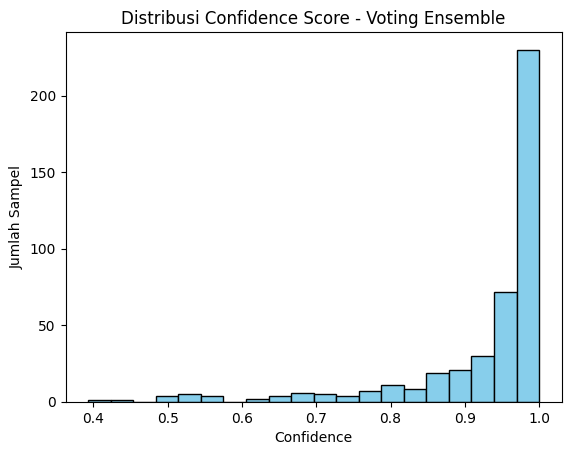

Rata-rata confidence: 0.9261
Confidence terendah: 0.3931, tertinggi: 1.0000

VISUALISASI DATA SEBELUM & SESUDAH AUGMENTASI


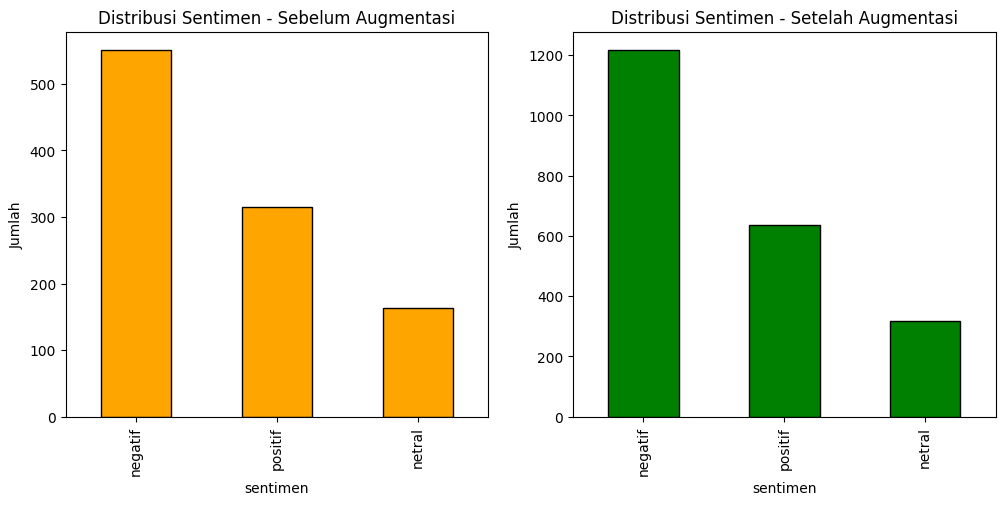

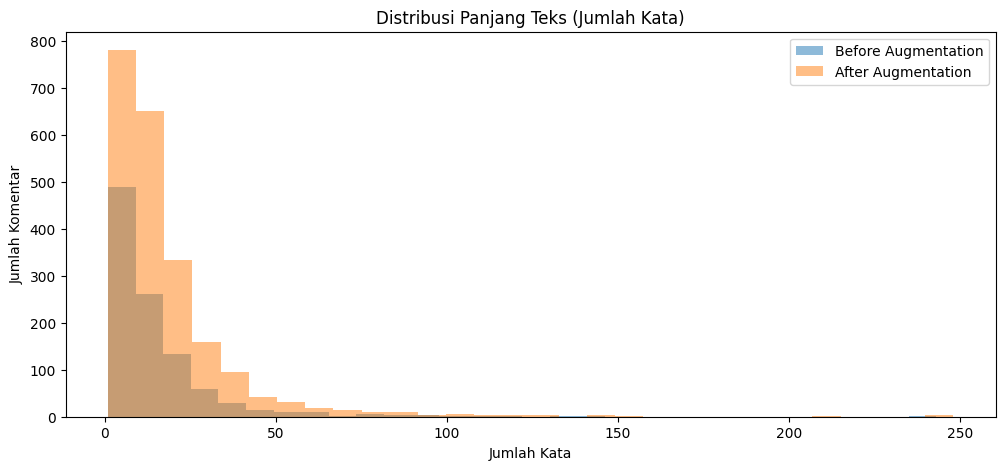

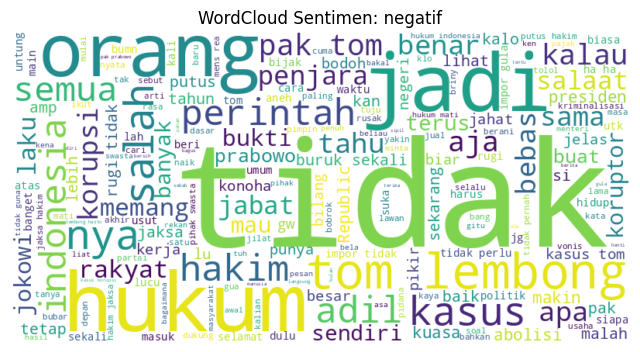

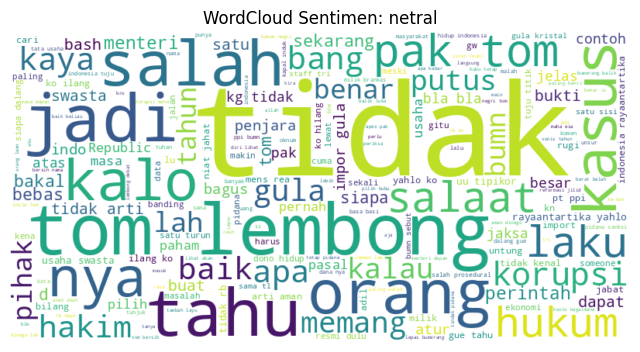

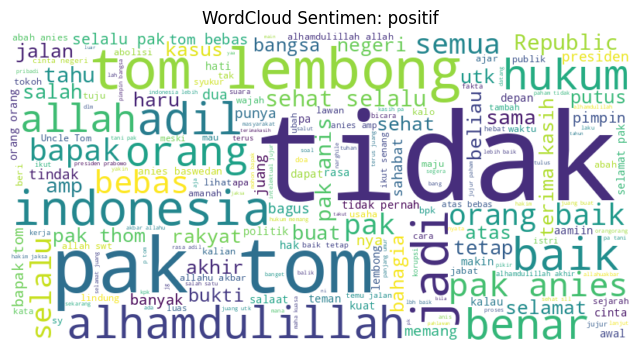

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ANALISIS CONFIDENCE PREDIKSI

print(f"\n{'='*80}")
print("ANALISIS CONFIDENCE PREDIKSI (Voting Ensemble)")
print(f"{'='*80}")

if hasattr(voting_ensemble, "predict_proba"):
    y_proba = voting_ensemble.predict_proba(X_test)
    confidence = np.max(y_proba, axis=1)

    plt.hist(confidence, bins=20, color="skyblue", edgecolor="black")
    plt.title("Distribusi Confidence Score - Voting Ensemble")
    plt.xlabel("Confidence")
    plt.ylabel("Jumlah Sampel")
    plt.show()

    print(f"Rata-rata confidence: {confidence.mean():.4f}")
    print(f"Confidence terendah: {confidence.min():.4f}, tertinggi: {confidence.max():.4f}")
else:
    print("Voting Ensemble tidak mendukung predict_proba.")


# VISUALISASI DATA SEBELUM & SESUDAH AUGMENTASI

print(f"\n{'='*80}")
print("VISUALISASI DATA SEBELUM & SESUDAH AUGMENTASI")
print(f"{'='*80}")

# Distribusi jumlah data per kelas
fig, ax = plt.subplots(1,2, figsize=(12,5))

df['sentimen'].value_counts().plot(kind="bar", ax=ax[0], color="orange", edgecolor="black")
ax[0].set_title("Distribusi Sentimen - Sebelum Augmentasi")
ax[0].set_ylabel("Jumlah")

df_final['sentimen'].value_counts().plot(kind="bar", ax=ax[1], color="green", edgecolor="black")
ax[1].set_title("Distribusi Sentimen - Setelah Augmentasi")
ax[1].set_ylabel("Jumlah")

plt.show()

# Distribusi panjang teks
plt.figure(figsize=(12,5))
plt.hist(df['clean_text'].str.split().map(len), bins=30, alpha=0.5, label="Before Augmentation")
plt.hist(df_final['clean_text'].str.split().map(len), bins=30, alpha=0.5, label="After Augmentation")
plt.title("Distribusi Panjang Teks (Jumlah Kata)")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Komentar")
plt.legend()
plt.show()

# Wordcloud per sentimen setelah augmentasi
for label in df_final['sentimen'].unique():
    text = " ".join(df_final[df_final['sentimen']==label]['clean_text'])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(8,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud Sentimen: {label}")
    plt.show()


PERSEBARAN DATA (PCA & TSNE VISUALIZATION)


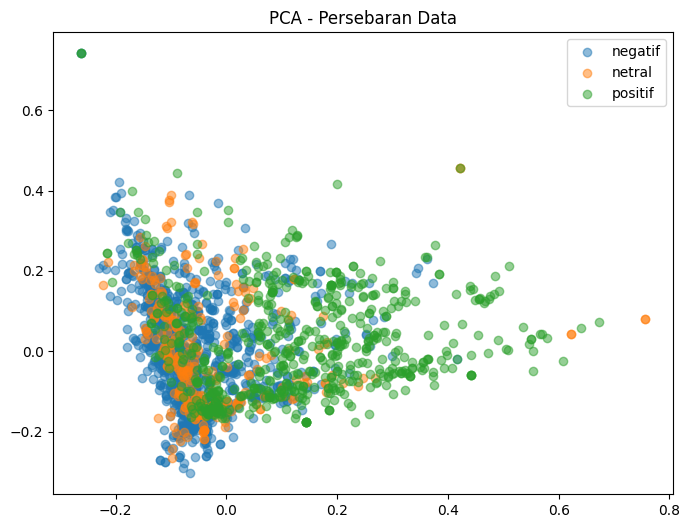

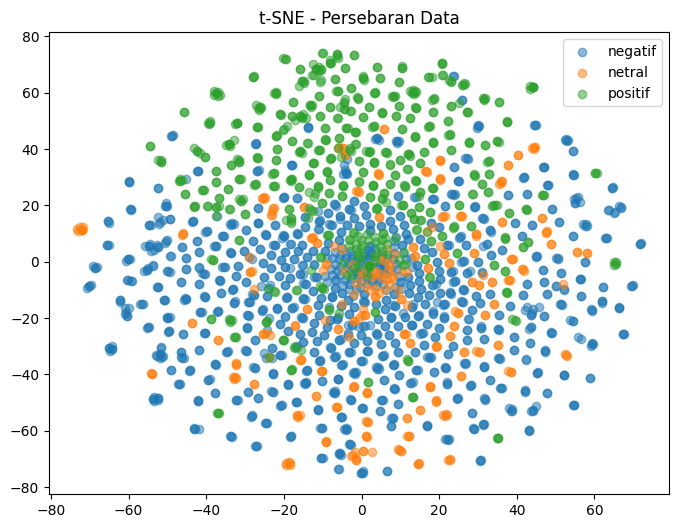

In [ ]:
# PERSEBARAN DATA (PCA/TSNE)

print(f"\n{'='*80}")
print("PERSEBARAN DATA (PCA & TSNE VISUALIZATION)")
print(f"{'='*80}")

# Vektorisasi dengan TF-IDF Unigram untuk visualisasi
vec = TfidfVectorizer(max_features=1000)
X_vec = vec.fit_transform(df_final['clean_text']).toarray()

# PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_vec)

plt.figure(figsize=(8,6))
for label in df_final['sentimen'].unique():
    idx = df_final['sentimen']==label
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label, alpha=0.5)
plt.title("PCA - Persebaran Data")
plt.legend()
plt.show()

# TSNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_vec)

plt.figure(figsize=(8,6))
for label in df_final['sentimen'].unique():
    idx = df_final['sentimen']==label
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], label=label, alpha=0.5)
plt.title("t-SNE - Persebaran Data")
plt.legend()
plt.show()

In [ ]:
# SAVE ALL PIPELINES

print(f"\n{'='*80}")
print("MENYIMPAN SEMUA PIPELINE")
print(f"{'='*80}")

all_pipelines = {}

for vec_name, results in all_results.items():
    for model_name, info in results.items():
        pipeline = Pipeline([
            ('vectorizer', all_vectorized_data[vec_name]['vectorizer']),
            ('classifier', info['model'])
        ])
        key_name = f"{model_name}_{vec_name}".replace(" ", "_")
        all_pipelines[key_name] = pipeline

all_pipelines["Voting_Ensemble"] = voting_ensemble

for name, pipeline in all_pipelines.items():
    filename = f"pipeline_{name}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(pipeline, f)
    print(f"Saved pipeline: {filename}")

with open("all_pipelines.pkl", "wb") as f:
    pickle.dump(all_pipelines, f)

print("\nSemua pipeline berhasil disimpan ke .pkl")
print("   - File terpisah: pipeline_[model]_[vectorizer].pkl")
print("   - Semua jadi satu: all_pipelines.pkl")



MENYIMPAN SEMUA PIPELINE
Saved pipeline: pipeline_SVM_tfidf_unigram.pkl
Saved pipeline: pipeline_Naive_Bayes_tfidf_unigram.pkl
Saved pipeline: pipeline_Logistic_Regression_tfidf_unigram.pkl
Saved pipeline: pipeline_Random_Forest_tfidf_unigram.pkl
Saved pipeline: pipeline_Gradient_Boosting_tfidf_unigram.pkl
Saved pipeline: pipeline_SVM_tfidf_bigram.pkl
Saved pipeline: pipeline_Naive_Bayes_tfidf_bigram.pkl
Saved pipeline: pipeline_Logistic_Regression_tfidf_bigram.pkl
Saved pipeline: pipeline_Random_Forest_tfidf_bigram.pkl
Saved pipeline: pipeline_Gradient_Boosting_tfidf_bigram.pkl
Saved pipeline: pipeline_SVM_tfidf_trigram.pkl
Saved pipeline: pipeline_Naive_Bayes_tfidf_trigram.pkl
Saved pipeline: pipeline_Logistic_Regression_tfidf_trigram.pkl
Saved pipeline: pipeline_Random_Forest_tfidf_trigram.pkl
Saved pipeline: pipeline_Gradient_Boosting_tfidf_trigram.pkl
Saved pipeline: pipeline_SVM_count_vec.pkl
Saved pipeline: pipeline_Naive_Bayes_count_vec.pkl
Saved pipeline: pipeline_Logistic_Re


VISUALISASI DATA SEBELUM & SESUDAH AUGMENTASI


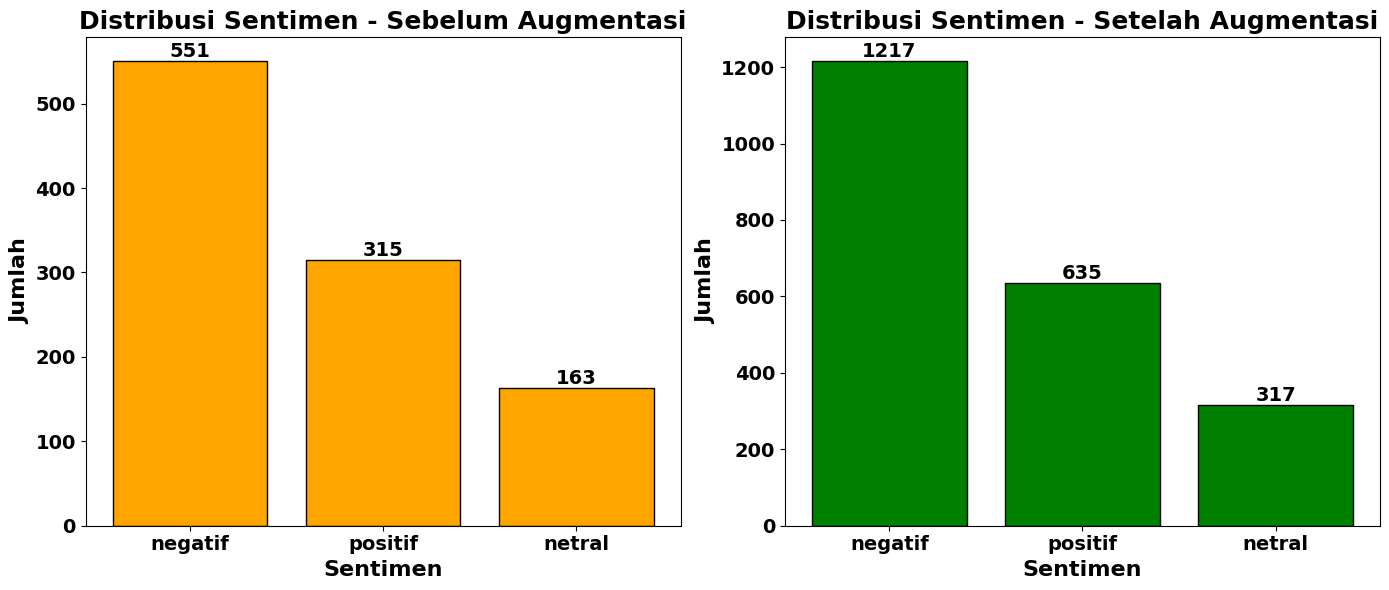

In [ ]:
# VISUALISASI DATA SEBELUM & SESUDAH AUGMENTASI

print(f"\n{'='*80}")
print("VISUALISASI DATA SEBELUM & SESUDAH AUGMENTASI")
print(f"{'='*80}")

fig, ax = plt.subplots(1, 2, figsize=(14,6))


# Sebelum augmentasi
sent_before = df['sentimen'].value_counts()
bars1 = ax[0].bar(sent_before.index, sent_before.values, color="orange", edgecolor="black")
ax[0].set_title("Distribusi Sentimen - Sebelum Augmentasi", fontsize=18, weight="bold")
ax[0].set_ylabel("Jumlah", fontsize=16, weight="bold")
ax[0].set_xlabel("Sentimen", fontsize=16, weight="bold")

ax[0].tick_params(axis='both', labelsize=14)
for label in ax[0].get_xticklabels() + ax[0].get_yticklabels():
    label.set_fontsize(14)
    label.set_weight("bold")

for bar in bars1:
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
               str(bar.get_height()), ha='center', va='bottom',
               fontsize=14, weight="bold")

# Setelah augmentasi
sent_after = df_final['sentimen'].value_counts()
bars2 = ax[1].bar(sent_after.index, sent_after.values, color="green", edgecolor="black")
ax[1].set_title("Distribusi Sentimen - Setelah Augmentasi", fontsize=18, weight="bold")
ax[1].set_ylabel("Jumlah", fontsize=16, weight="bold")
ax[1].set_xlabel("Sentimen", fontsize=16, weight="bold")

ax[1].tick_params(axis='both', labelsize=14)
for label in ax[1].get_xticklabels() + ax[1].get_yticklabels():
    label.set_fontsize(14)
    label.set_weight("bold")

for bar in bars2:
    ax[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
               str(bar.get_height()), ha='center', va='bottom',
               fontsize=14, weight="bold")

plt.tight_layout()
plt.show()


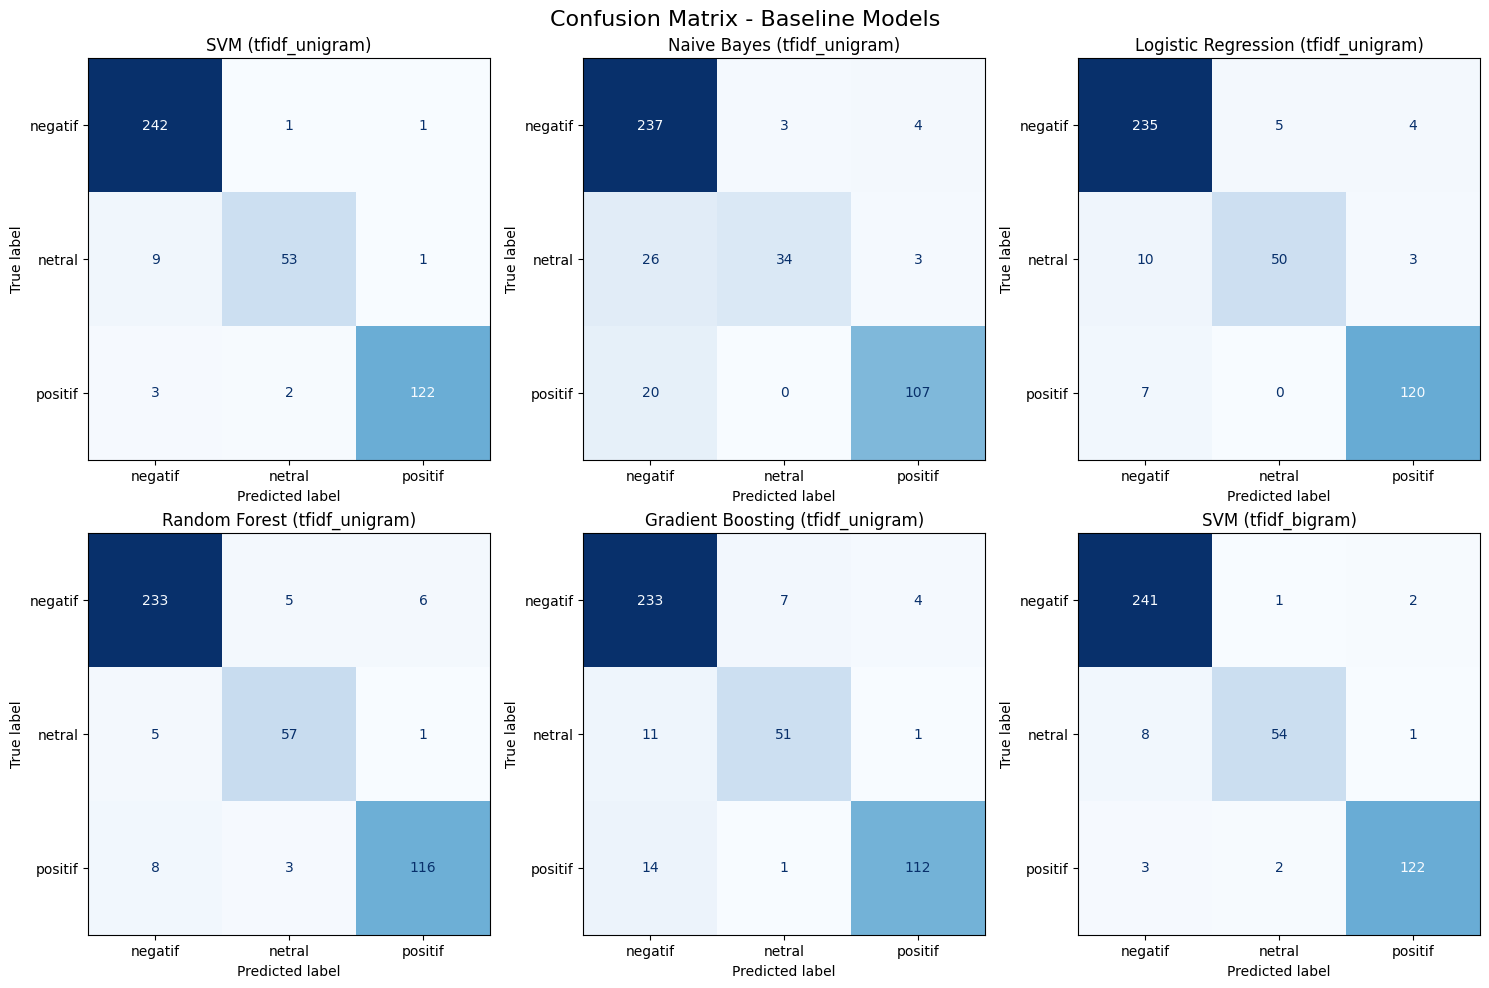

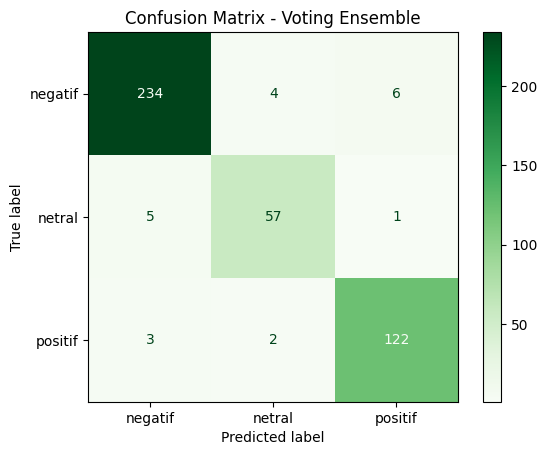

In [ ]:

# CONFUSION MATRIX VISUALIZATION
from sklearn.metrics import ConfusionMatrixDisplay

# Baseline / Single Models
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i, (vec_name, results) in enumerate(all_results.items()):
    for j, (model_name, info) in enumerate(results.items()):
        if i*len(results)+j >= len(axes):
            break
        y_pred = info['predictions']
        cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
        disp.plot(cmap="Blues", values_format='d', ax=axes[i*len(results)+j], colorbar=False)
        axes[i*len(results)+j].set_title(f"{model_name} ({vec_name})")

plt.suptitle("Confusion Matrix - Baseline Models", fontsize=16)
plt.tight_layout()
plt.show()

# Ensemble Models
cm = confusion_matrix(y_test, ensemble_pred, labels=sorted(y_test.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(cmap="Greens", values_format='d')
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()


In [ ]:
# CLASSIFICATION REPORT ALL MODELS (ONE TABLE)
from sklearn.metrics import classification_report

print(f"\n{'='*80}")
print("CLASSIFICATION REPORT - ALL MODELS (MERGED)")
print(f"{'='*80}")

reports = []

# Kumpulkan report semua model per vectorizer
for vec_name, results in all_results.items():
    for model_name, info in results.items():
        y_pred = info['predictions']
        report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # Simpan per kelas + avg metrics
        for label, metrics in report_dict.items():
            if isinstance(metrics, dict):  # hanya ambil yang dict (bukan 'accuracy')
                reports.append({
                    "Model": model_name,
                    "Vectorizer": vec_name,
                    "Class": label,
                    "Precision": metrics["precision"],
                    "Recall": metrics["recall"],
                    "F1-score": metrics["f1-score"],
                    "Support": metrics["support"]
                })

# Tambahkan ensemble
ensemble_report = classification_report(y_test, ensemble_pred, output_dict=True, zero_division=0)
for label, metrics in ensemble_report.items():
    if isinstance(metrics, dict):
        reports.append({
            "Model": "Voting Ensemble",
            "Vectorizer": "Multi-Vectorizer",
            "Class": label,
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1-score": metrics["f1-score"],
            "Support": metrics["support"]
        })

# Buat dataframe
reports_df = pd.DataFrame(reports)
reports_df = reports_df.round(4)

# Simpan ke CSV biar bisa dibuka di Excel
reports_df.to_csv("all_classification_reports.csv", index=False)

print("Classification report semua model.")
display(reports_df.head())



CLASSIFICATION REPORT - ALL MODELS (MERGED)
Classification report semua model.


,Model,Vectorizer,Class,Precision,Recall,F1-score,Support
0,SVM,tfidf_unigram,negatif,0.9528,0.9918,0.9719,244.0
1,SVM,tfidf_unigram,netral,0.9464,0.8413,0.8908,63.0
2,SVM,tfidf_unigram,positif,0.9839,0.9606,0.9721,127.0
3,SVM,tfidf_unigram,macro avg,0.9610,0.9312,0.9449,434.0
4,SVM,tfidf_unigram,weighted avg,0.9609,0.9608,0.9602,434.0


In [ ]:

# CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(f"\n{'='*80}")
print("CLASSIFICATION REPORT PER MODEL")
print(f"{'='*80}")

# Semua model per vectorizer
for vec_name, results in all_results.items():
    for model_name, info in results.items():
        print(f"\nModel: {model_name} | Vectorizer: {vec_name}")
        y_pred = info['predictions']
        print(classification_report(y_test, y_pred, digits=2, zero_division=0))

# Ensemble
print(f"\nModel: Voting Ensemble | Vectorizer: Multi-Vectorizer")
print(classification_report(y_test, ensemble_pred, digits=2, zero_division=0))



CLASSIFICATION REPORT PER MODEL

Model: SVM | Vectorizer: tfidf_unigram
              precision    recall  f1-score   support

     negatif       0.95      0.99      0.97       244
      netral       0.95      0.84      0.89        63
     positif       0.98      0.96      0.97       127

    accuracy                           0.96       434
   macro avg       0.96      0.93      0.94       434
weighted avg       0.96      0.96      0.96       434


Model: Naive Bayes | Vectorizer: tfidf_unigram
              precision    recall  f1-score   support

     negatif       0.84      0.97      0.90       244
      netral       0.92      0.54      0.68        63
     positif       0.94      0.84      0.89       127

    accuracy                           0.87       434
   macro avg       0.90      0.78      0.82       434
weighted avg       0.88      0.87      0.86       434


Model: Logistic Regression | Vectorizer: tfidf_unigram
              precision    recall  f1-score   support

     n

In [ ]:

# SUMMARY CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(f"\n{'='*80}")
print("CLASSIFICATION REPORT SUMMARY - ALL MODELS")
print(f"{'='*80}")

summary_rows = []

# Loop semua model
for vec_name, results in all_results.items():
    for model_name, info in results.items():
        y_pred = info['predictions']
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        summary_rows.append({
            "Model": model_name,
            "Vectorizer": vec_name,
            "Accuracy": report["accuracy"],
            "Macro Precision": report["macro avg"]["precision"],
            "Macro Recall": report["macro avg"]["recall"],
            "Macro F1": report["macro avg"]["f1-score"],
            "Weighted Precision": report["weighted avg"]["precision"],
            "Weighted Recall": report["weighted avg"]["recall"],
            "Weighted F1": report["weighted avg"]["f1-score"]
        })

ensemble_report = classification_report(y_test, ensemble_pred, output_dict=True, zero_division=0)
summary_rows.append({
    "Model": "Voting Ensemble",
    "Vectorizer": "Multi-Vectorizer",
    "Accuracy": ensemble_report["accuracy"],
    "Macro Precision": ensemble_report["macro avg"]["precision"],
    "Macro Recall": ensemble_report["macro avg"]["recall"],
    "Macro F1": ensemble_report["macro avg"]["f1-score"],
    "Weighted Precision": ensemble_report["weighted avg"]["precision"],
    "Weighted Recall": ensemble_report["weighted avg"]["recall"],
    "Weighted F1": ensemble_report["weighted avg"]["f1-score"]
})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.round(3)

summary_df = summary_df.sort_values(by=["Vectorizer", "Model"]).reset_index(drop=True)

summary_df.to_csv("classification_report_summary.csv", index=False)

print("Ringkasan classification report semua model sudah dibuat.")
display(summary_df)



CLASSIFICATION REPORT SUMMARY - ALL MODELS
Ringkasan classification report semua model sudah dibuat.


,Model,Vectorizer,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Voting Ensemble,Multi-Vectorizer,0.952,0.939,0.941,0.940,0.952,0.952,0.952
1,Gradient Boosting,count_vec,0.926,0.954,0.872,0.904,0.932,0.926,0.924
2,Logistic Regression,count_vec,0.940,0.924,0.932,0.928,0.941,0.940,0.940
3,Naive Bayes,count_vec,0.869,0.860,0.816,0.834,0.868,0.869,0.866
4,Random Forest,count_vec,0.926,0.913,0.904,0.908,0.926,0.926,0.926
5,SVM,count_vec,0.940,0.948,0.907,0.925,0.941,0.940,0.939
6,Gradient Boosting,tfidf_bigram,0.899,0.872,0.880,0.876,0.900,0.899,0.899
7,Logistic Regression,tfidf_bigram,0.940,0.946,0.910,0.925,0.941,0.940,0.939
8,Naive Bayes,tfidf_bigram,0.882,0.895,0.804,0.836,0.886,0.882,0.877
9,Random Forest,tfidf_bigram,0.931,0.913,0.923,0.917,0.932,0.931,0.931



CONFUSION MATRIX PER MODEL


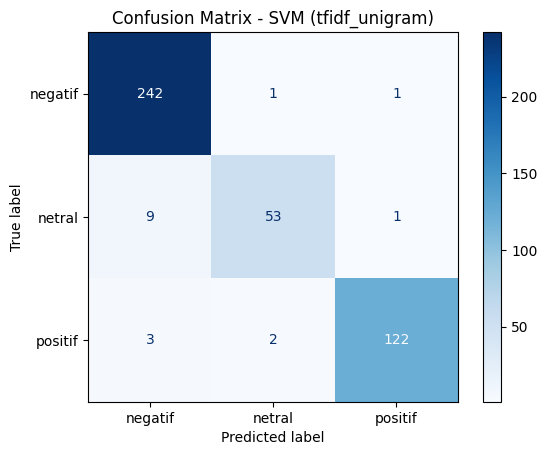

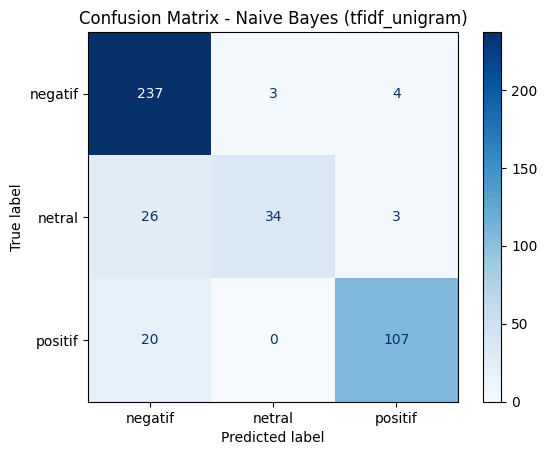

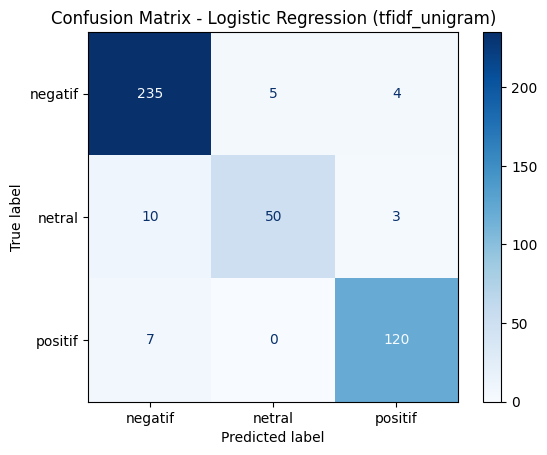

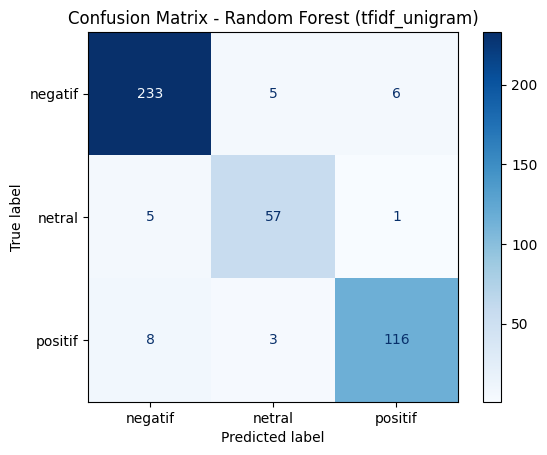

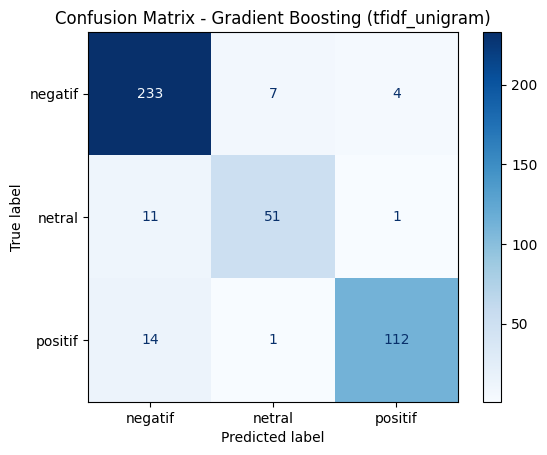

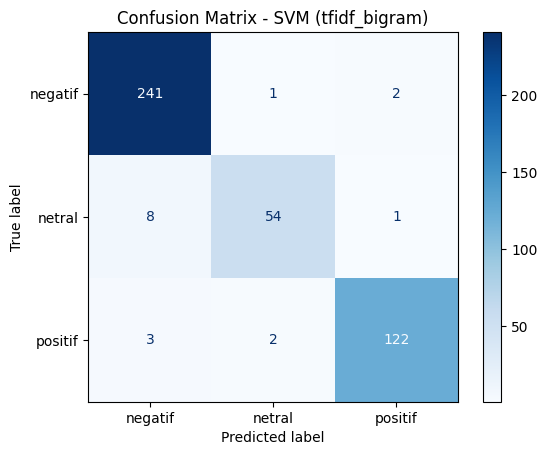

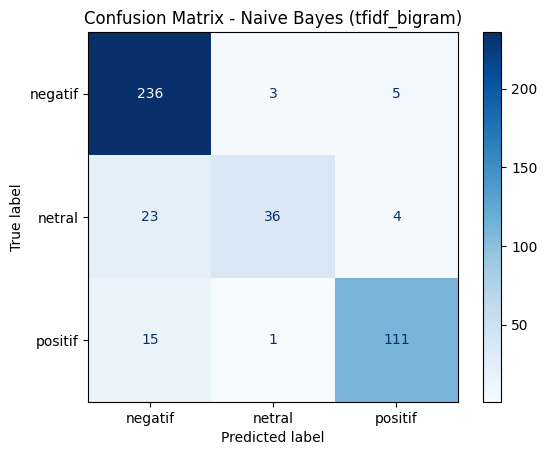

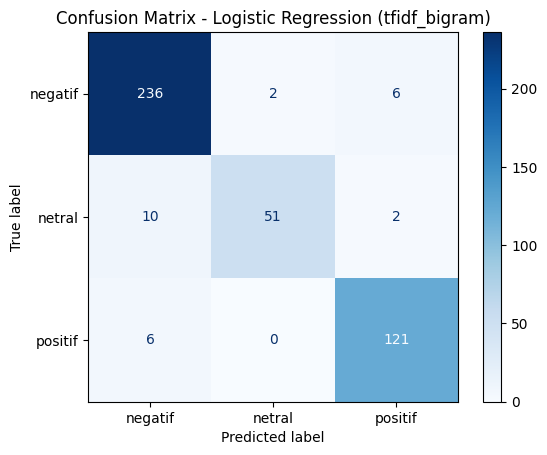

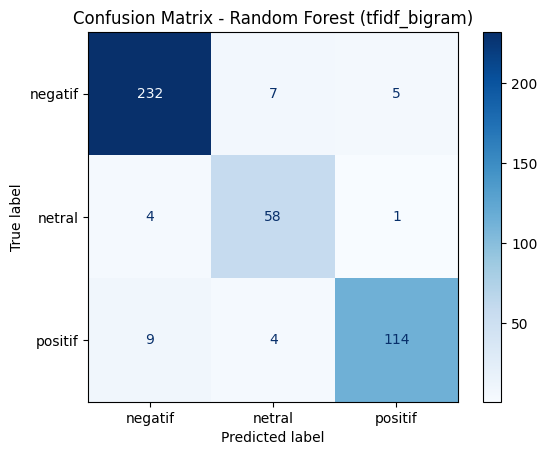

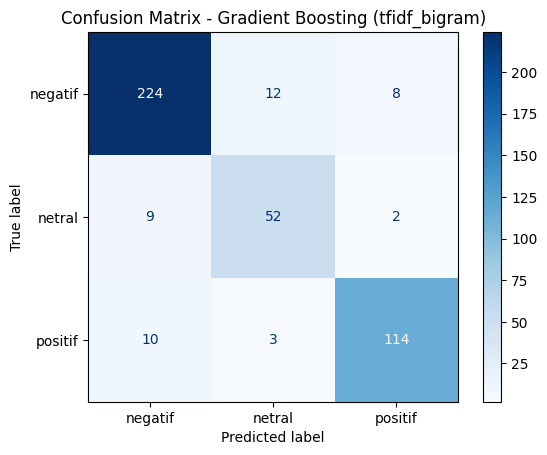

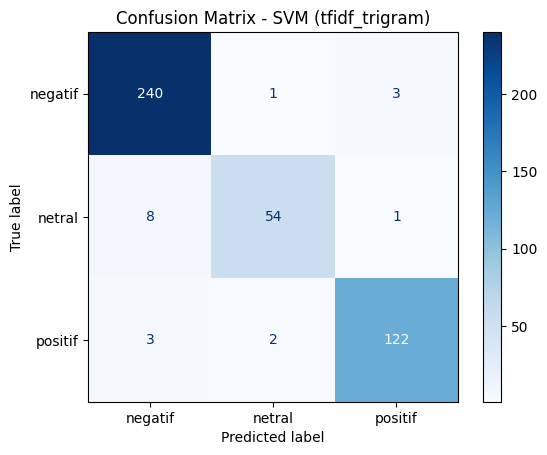

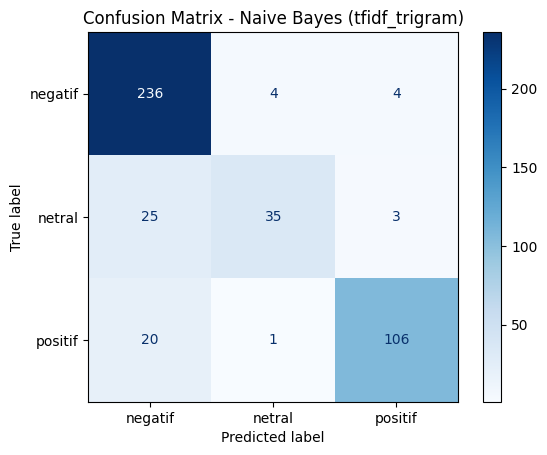

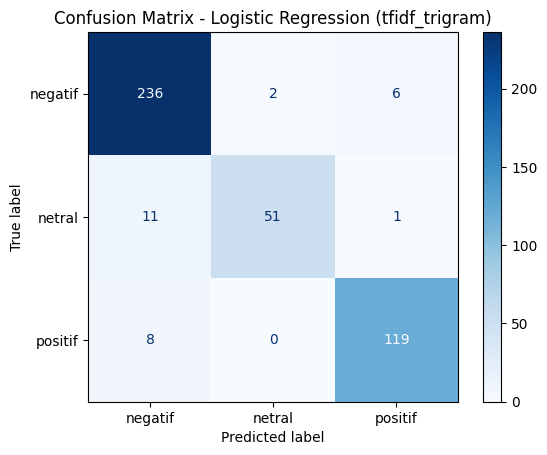

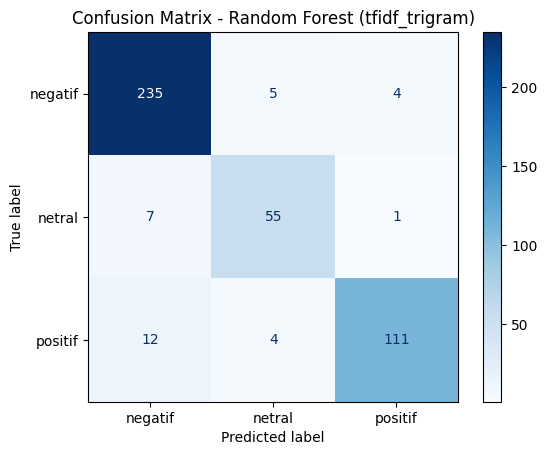

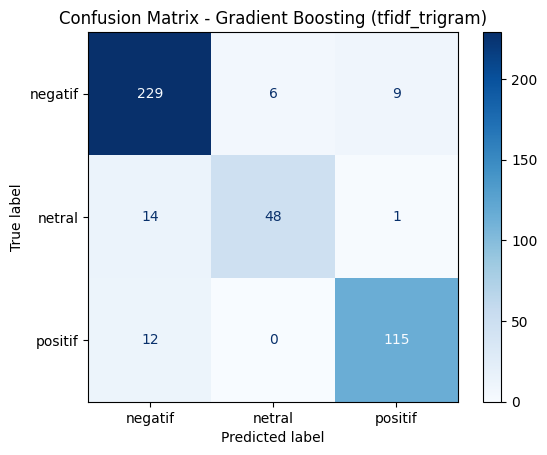

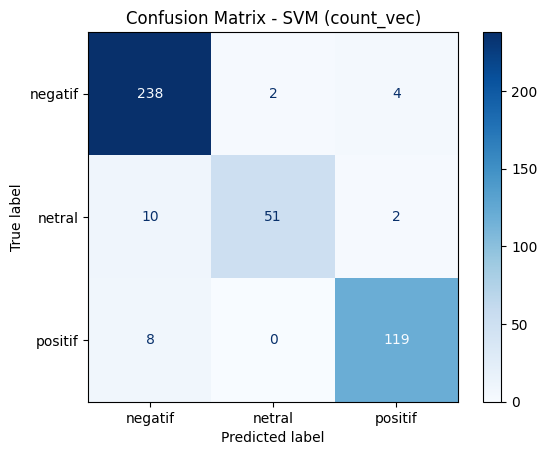

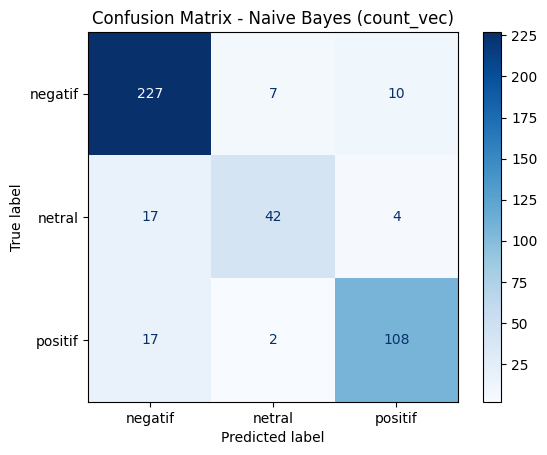

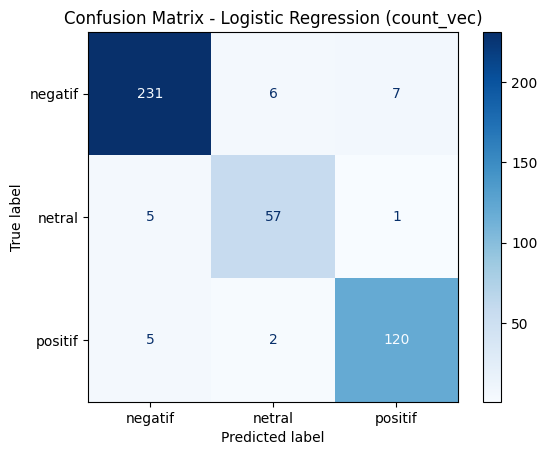

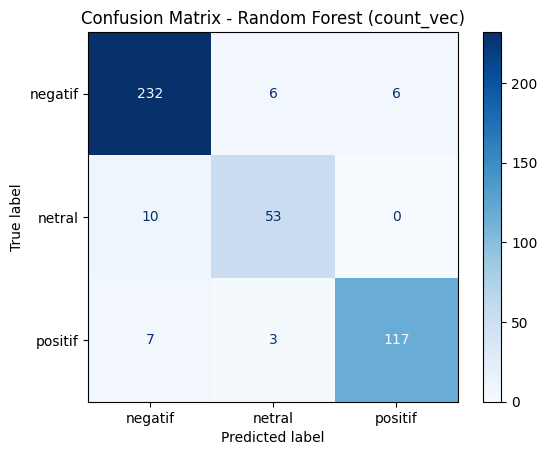

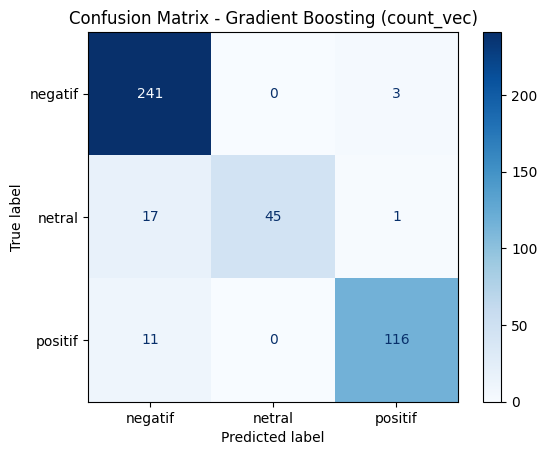

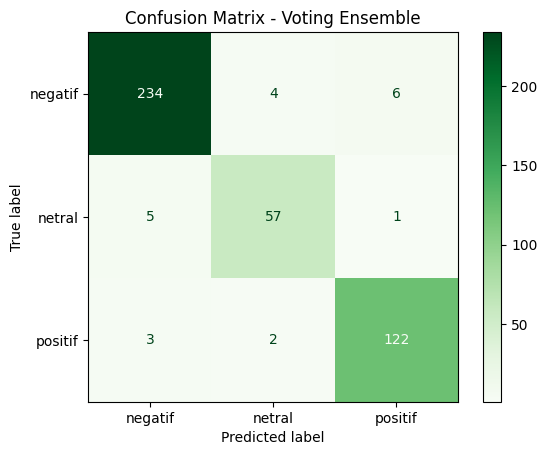

In [ ]:
# CONFUSION MATRIX PER MODEL

from sklearn.metrics import ConfusionMatrixDisplay

print(f"\n{'='*80}")
print("CONFUSION MATRIX PER MODEL")
print(f"{'='*80}")

models_to_plot = ["SVM", "Naive Bayes", "Logistic Regression", "Random Forest", "Gradient Boosting"]

for vec_name, results in all_results.items():
    for model_name, info in results.items():
        if model_name in models_to_plot:
            y_pred = info['predictions']
            cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
            disp.plot(cmap="Blues", values_format='d')
            plt.title(f"Confusion Matrix - {model_name} ({vec_name})")
            plt.show()

cm = confusion_matrix(y_test, ensemble_pred, labels=sorted(y_test.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(cmap="Greens", values_format='d')
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()


ANALISIS CONFIDENCE PREDIKSI (Voting Ensemble)


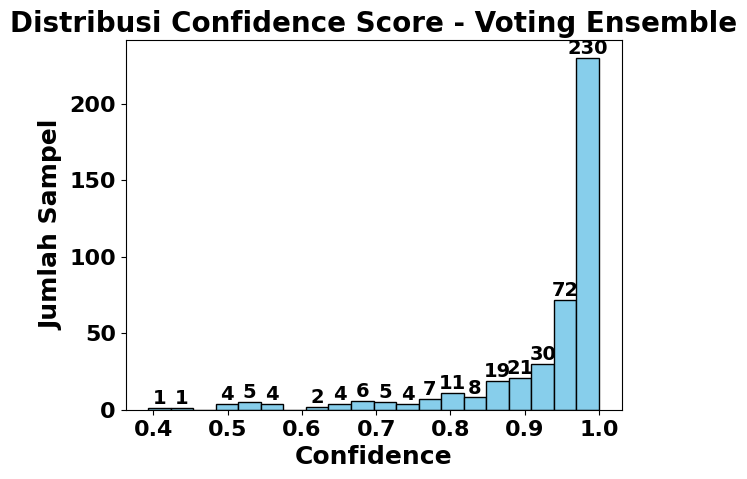

Rata-rata confidence: 0.9261
Confidence terendah: 0.3931, tertinggi: 1.0000


In [ ]:
# ANALISIS CONFIDENCE PREDIKSI

print("ANALISIS CONFIDENCE PREDIKSI (Voting Ensemble)")

if hasattr(voting_ensemble, "predict_proba"):
    y_proba = voting_ensemble.predict_proba(X_test)
    confidence = np.max(y_proba, axis=1)

    counts, bins, patches = plt.hist(confidence, bins=20, color="skyblue", edgecolor="black")

    plt.title("Distribusi Confidence Score - Voting Ensemble", fontsize=20, weight="bold")
    plt.xlabel("Confidence", fontsize=18, weight="bold")
    plt.ylabel("Jumlah Sampel", fontsize=18, weight="bold")

    plt.xticks(fontsize=16, weight="bold")
    plt.yticks(fontsize=16, weight="bold")

    for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
        if count > 0:
            plt.text((bin_left + bin_right)/2, count, str(int(count)),
                     ha='center', va='bottom', fontsize=14, weight="bold")

    plt.show()

    print(f"Rata-rata confidence: {confidence.mean():.4f}")
    print(f"Confidence terendah: {confidence.min():.4f}, tertinggi: {confidence.max():.4f}")


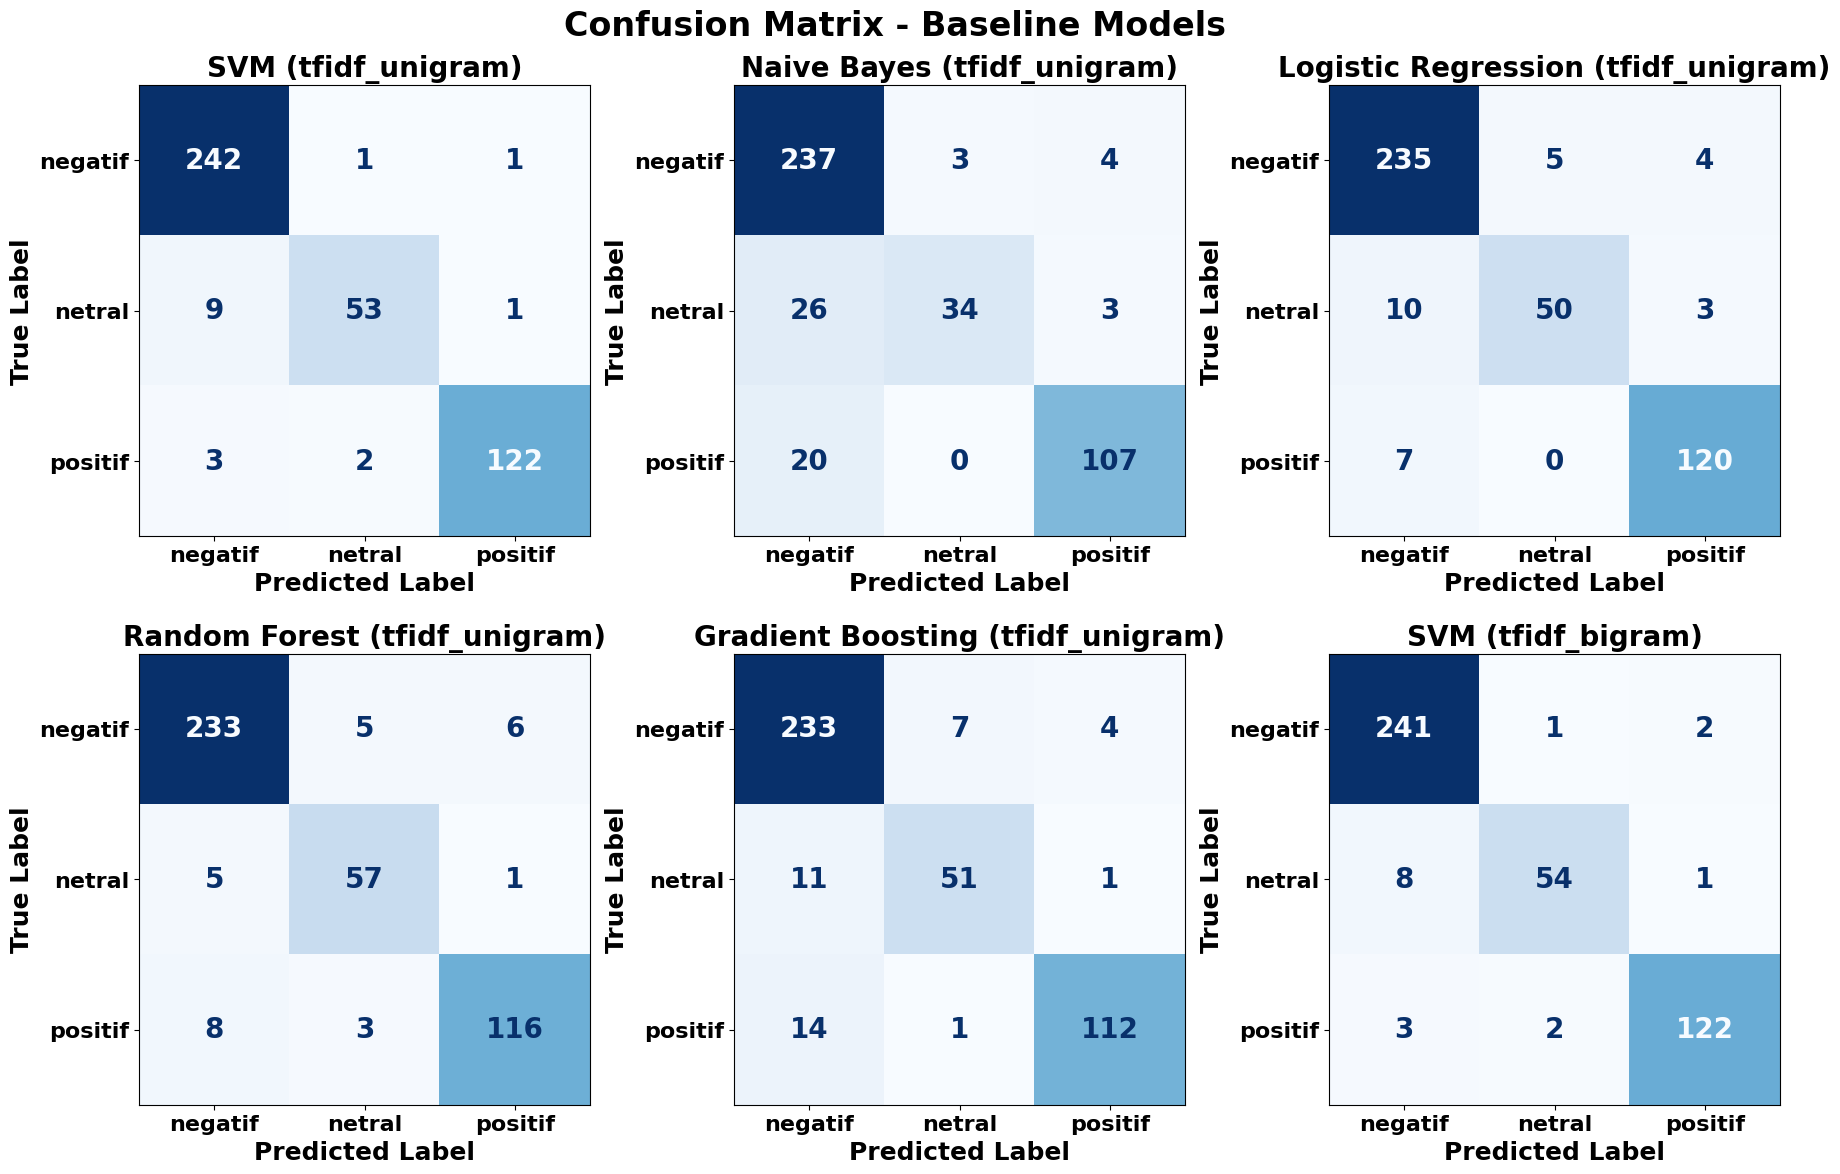

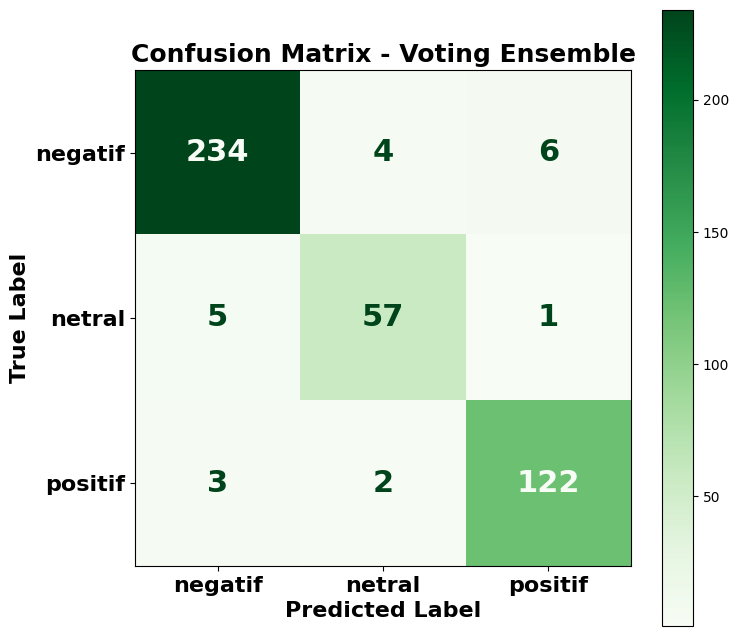

In [ ]:

# CONFUSION MATRIX VISUALIZATION
from sklearn.metrics import ConfusionMatrixDisplay

# Baseline / Single Models
fig, axes = plt.subplots(2, 3, figsize=(18,12))
axes = axes.flatten()

for i, (vec_name, results) in enumerate(all_results.items()):
    for j, (model_name, info) in enumerate(results.items()):
        if i*len(results)+j >= len(axes):
            break

        y_pred = info['predictions']
        cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
        disp.plot(cmap="Blues", values_format='d', ax=axes[i*len(results)+j], colorbar=False)


        axes[i*len(results)+j].set_title(f"{model_name} ({vec_name})", fontsize=20, weight="bold")

        axes[i*len(results)+j].set_xlabel("Predicted Label", fontsize=18, weight="bold")
        axes[i*len(results)+j].set_ylabel("True Label", fontsize=18, weight="bold")

        axes[i*len(results)+j].tick_params(axis='both', labelsize=16)
        for label in axes[i*len(results)+j].get_xticklabels() + axes[i*len(results)+j].get_yticklabels():
            label.set_fontsize(16)
            label.set_weight("bold")


        for text in disp.ax_.texts:
            text.set_fontsize(20)
            text.set_weight("bold")

plt.suptitle("Confusion Matrix - Baseline Models", fontsize=24, weight="bold")
plt.tight_layout()
plt.show()

# Ensemble Models
cm = confusion_matrix(y_test, ensemble_pred, labels=sorted(y_test.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(cmap="Greens", values_format='d', ax=ax)

ax.set_title("Confusion Matrix - Voting Ensemble", fontsize=18, weight="bold")
ax.set_xlabel("Predicted Label", fontsize=16, weight="bold")
ax.set_ylabel("True Label", fontsize=16, weight="bold")

ax.tick_params(axis='both', labelsize=16)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_weight("bold")

for text in disp.ax_.texts:
    text.set_fontsize(22)
    text.set_weight("bold")

plt.show()


In [ ]:

# CLASSIFICATION REPORT - BEST MODEL PER ALGORITHM
from sklearn.metrics import classification_report

print(f"\n{'='*80}")
print(" CLASSIFICATION REPORT - BASELINE MODEL")
print(f"{'='*80}")

best_per_algorithm = {}

# Cari model terbaik per algoritma
for algo in ["SVM", "Naive Bayes", "Logistic Regression", "Random Forest", "Gradient Boosting"]:
    algo_results = [r for r in all_model_results if r['Model'] == algo]
    if not algo_results:
        continue
    best_model = max(algo_results, key=lambda x: x['accuracy'])
    best_per_algorithm[algo] = best_model

    vec = best_model['Vectorizer']
    model_name = best_model['Model']

    # Ambil prediksi
    best_model_info = all_results[vec][model_name]
    y_pred = best_model_info['predictions']

    # Print classification report
    print(f"\n{model_name} | Vectorizer: {vec}")
    print(classification_report(y_test, y_pred, digits=2, zero_division=0))



 CLASSIFICATION REPORT - BASELINE MODEL

SVM | Vectorizer: tfidf_unigram
              precision    recall  f1-score   support

     negatif       0.95      0.99      0.97       244
      netral       0.95      0.84      0.89        63
     positif       0.98      0.96      0.97       127

    accuracy                           0.96       434
   macro avg       0.96      0.93      0.94       434
weighted avg       0.96      0.96      0.96       434


Naive Bayes | Vectorizer: tfidf_bigram
              precision    recall  f1-score   support

     negatif       0.86      0.97      0.91       244
      netral       0.90      0.57      0.70        63
     positif       0.93      0.87      0.90       127

    accuracy                           0.88       434
   macro avg       0.90      0.80      0.84       434
weighted avg       0.89      0.88      0.88       434


Logistic Regression | Vectorizer: tfidf_bigram
              precision    recall  f1-score   support

     negatif       0.